TensorFlow  : 2.21.0
Keras Tuner : 1.4.8
saved_models/ directory ready

SECTION 1 — LOAD DATA & EDA
Shape  : (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard

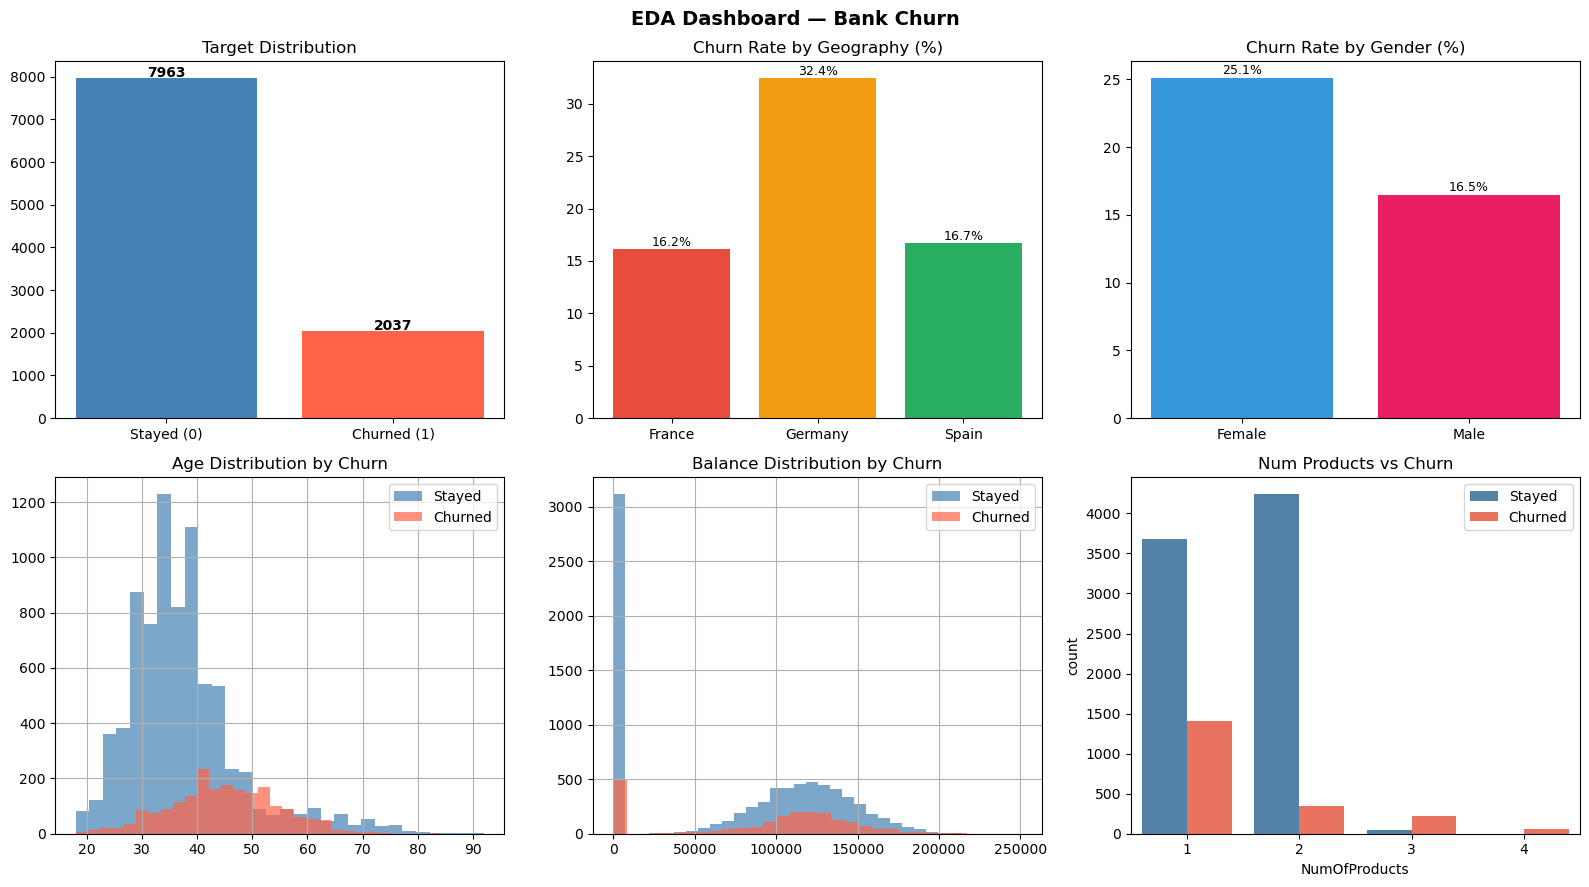

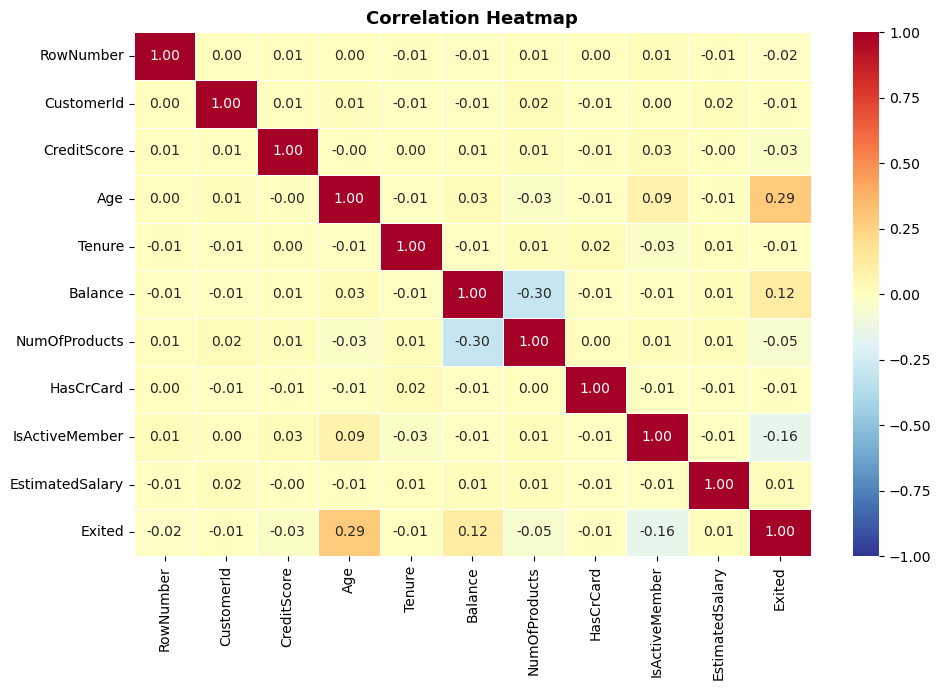

✅ EDA plots saved.

SECTION 2 — PREPROCESSING
=== Skewness ===
 CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
dtype: float64

log1p applied to: ['Age']
Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Churn', 'Geography_Germany', 'Geography_Spain']
Shape: (10000, 12)
✅ Outlier capping done
Train: 8000  |  Test: 2000
Train class dist: {0: np.int64(6370), 1: np.int64(1630)}
X_train: (8000, 11)  |  X_test: (2000, 11)
✅ Scaler saved to saved_models/scaler.pkl

✅ Helper functions ready.

SECTION 4 — PHASE A: WITHOUT IMBALANCE HANDLING

>>> A1: Batch GD (SGD, batch=full dataset)


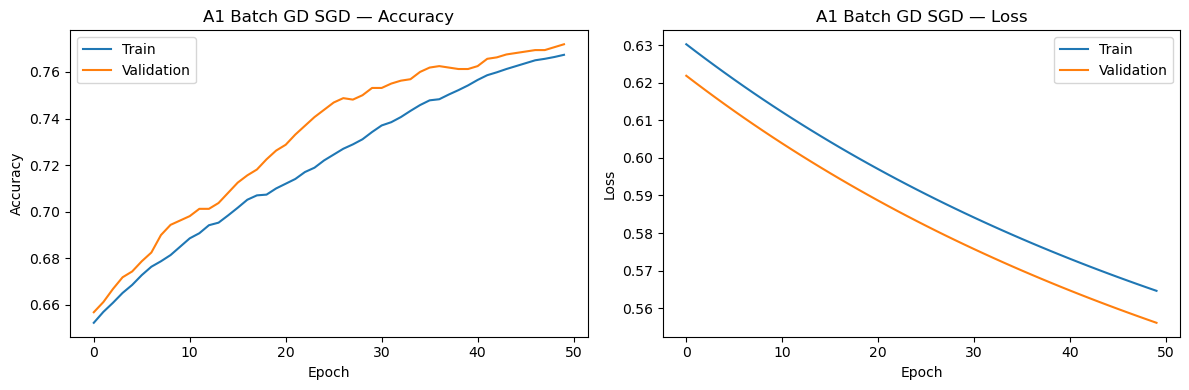


  A1: Batch GD (SGD)
              precision    recall  f1-score   support

      Stayed       0.80      0.94      0.86      1593
     Churned       0.19      0.06      0.09       407

    accuracy                           0.76      2000
   macro avg       0.49      0.50      0.47      2000
weighted avg       0.67      0.76      0.70      2000

ROC-AUC : 0.4873


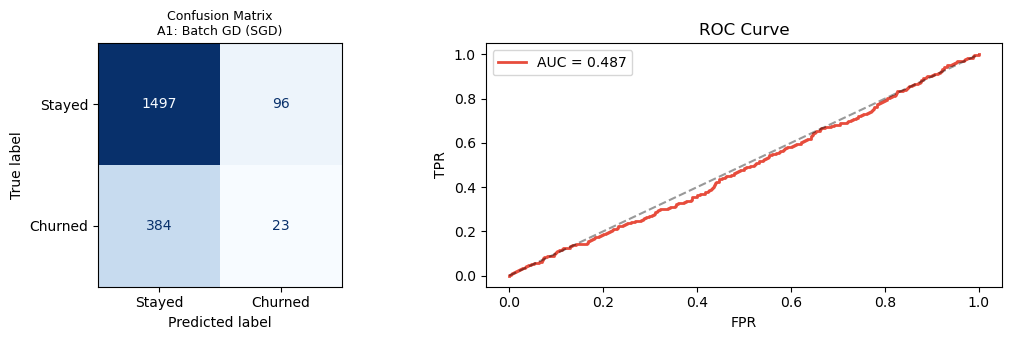


>>> A2: Stochastic GD (SGD, batch=1) — 20 epochs (slow by design)


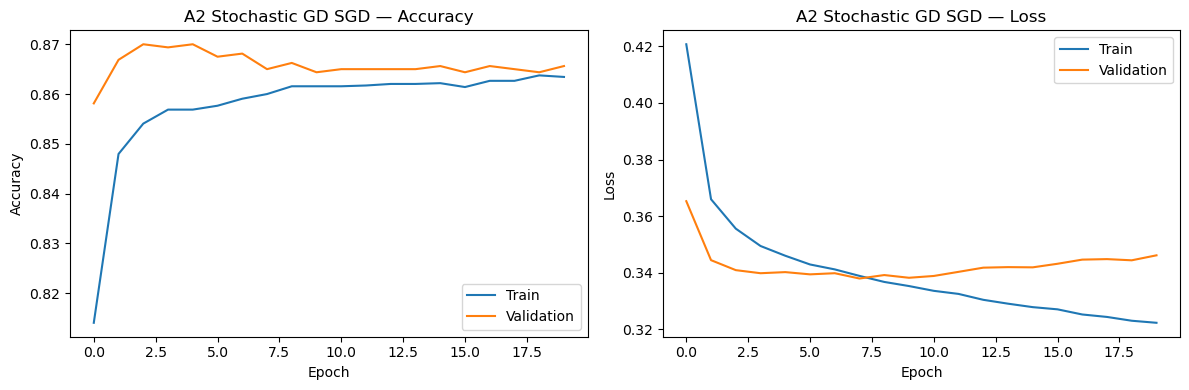


  A2: Stochastic GD (SGD, batch=1)
              precision    recall  f1-score   support

      Stayed       0.86      0.97      0.91      1593
     Churned       0.75      0.40      0.52       407

    accuracy                           0.85      2000
   macro avg       0.81      0.68      0.72      2000
weighted avg       0.84      0.85      0.83      2000

ROC-AUC : 0.8482


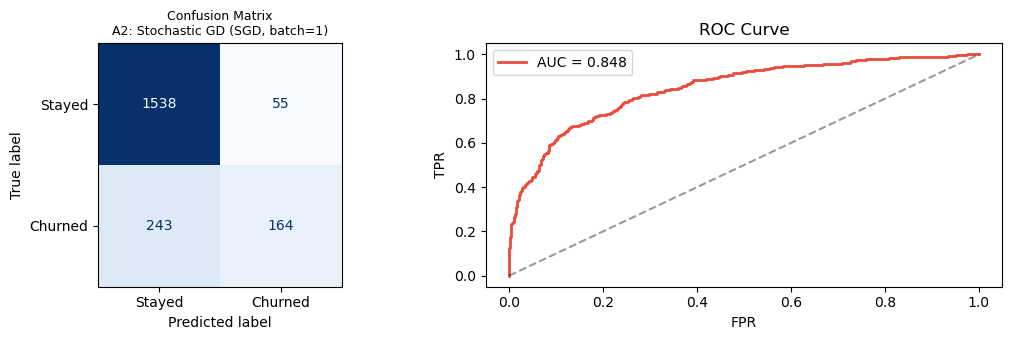


>>> A3: Mini-Batch GD (Adam) + ModelCheckpoint


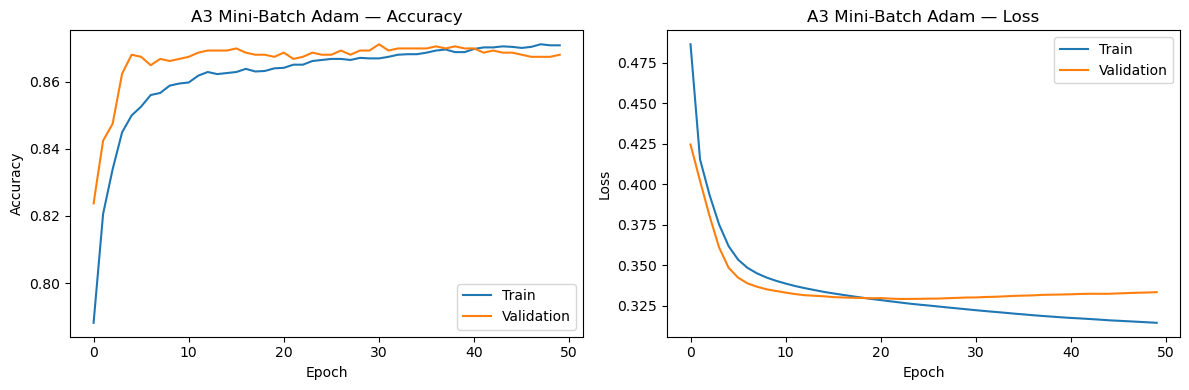


  A3: Mini-Batch GD (Adam)
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.75      0.48      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC : 0.8550


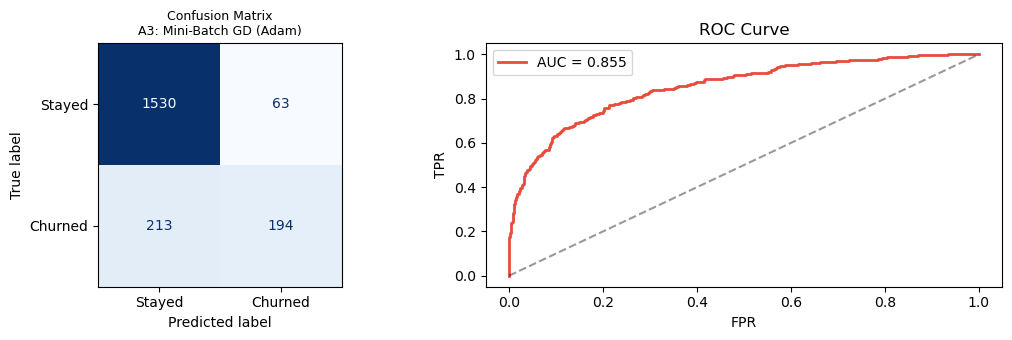


>>> A4: Mini-Batch GD (RMSprop) + ModelCheckpoint


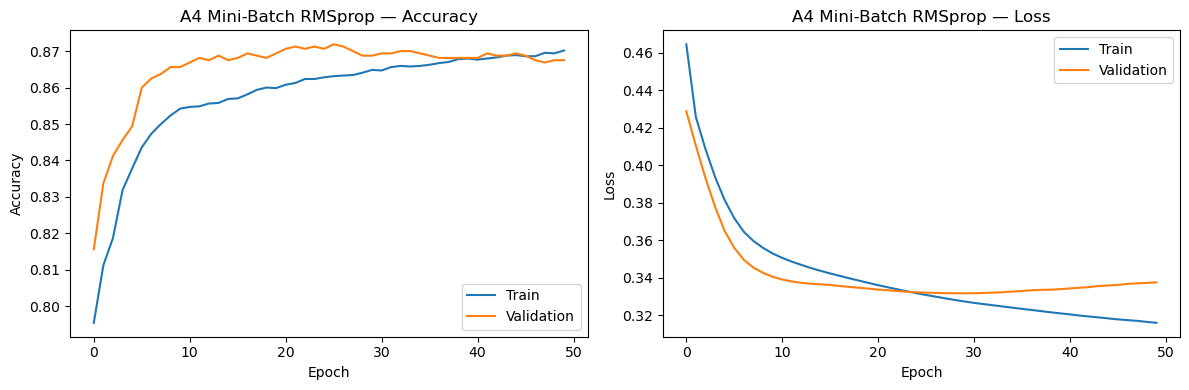


  A4: Mini-Batch GD (RMSprop)
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.92      1593
     Churned       0.75      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC : 0.8583


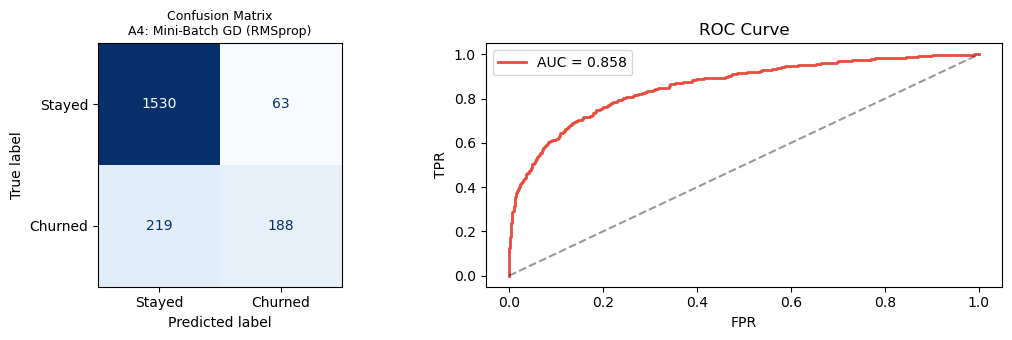


>>> A5: Early Stopping (patience=10)
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 20.
  Stopped at epoch: 30


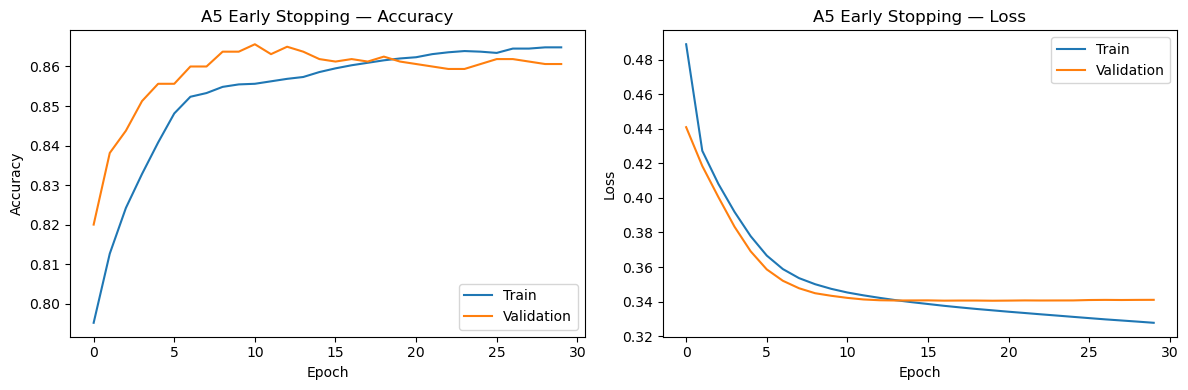


  A5: Early Stopping
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91      1593
     Churned       0.73      0.48      0.58       407

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC : 0.8504


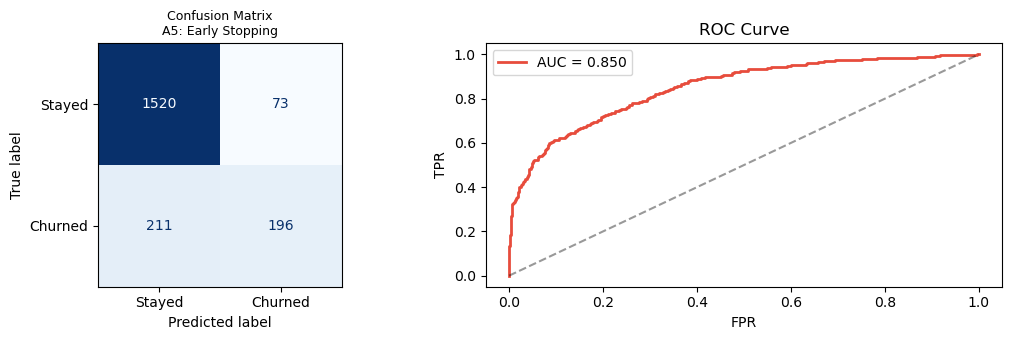


>>> A6: Dropout Regularization (0.3 + 0.2)


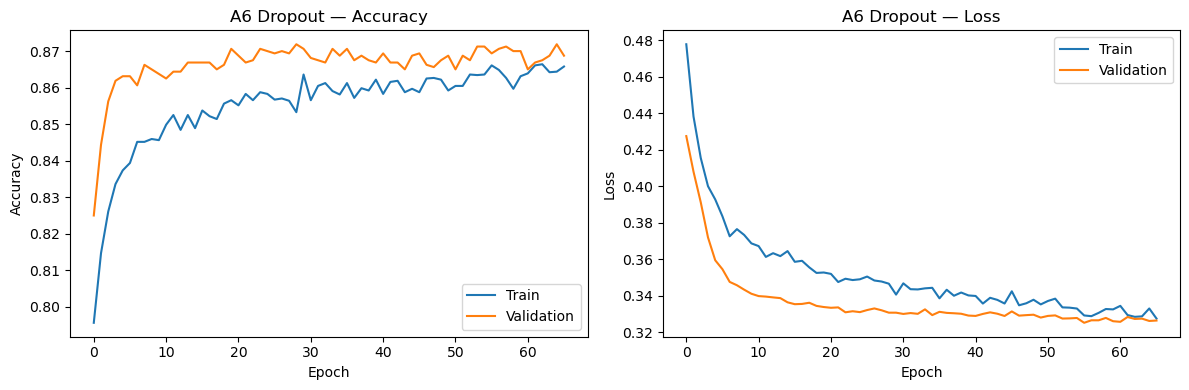


  A6: Dropout (0.3 + 0.2)
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.79      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC : 0.8607


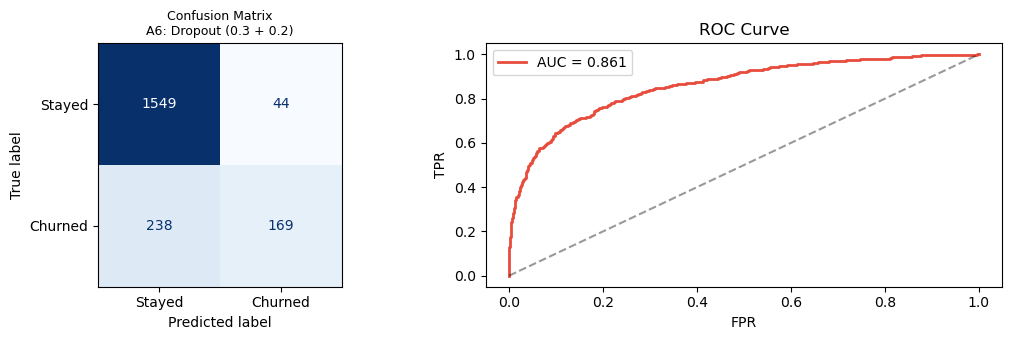


>>> A7–A10: Weight Initialization Techniques

  Training: A7: Glorot Uniform (Xavier)
    Best val_loss: 0.3390 at epoch 21


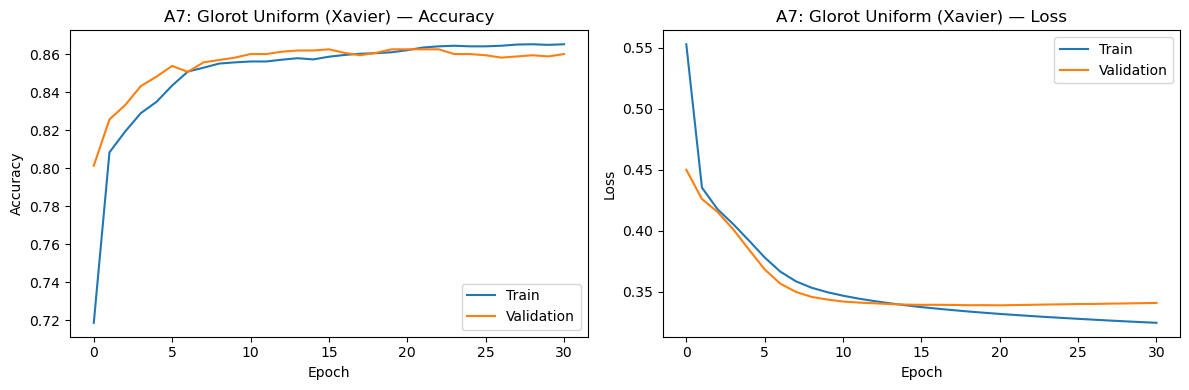


  A7: Glorot Uniform (Xavier)
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000

ROC-AUC : 0.8584


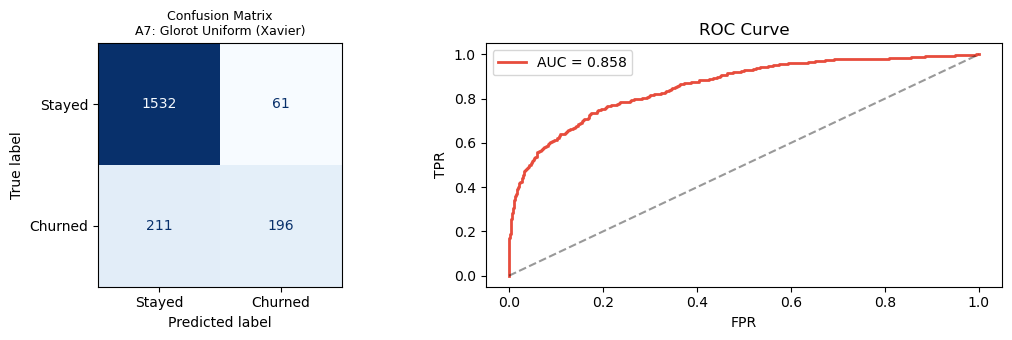


  Training: A8: He Normal (Kaiming)
    Best val_loss: 0.3452 at epoch 40


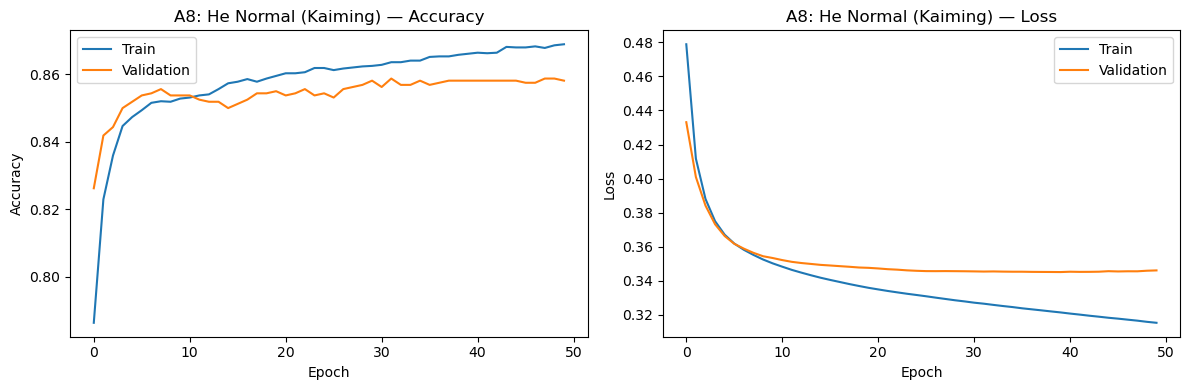


  A8: He Normal (Kaiming)
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91      1593
     Churned       0.72      0.48      0.58       407

    accuracy                           0.86      2000
   macro avg       0.80      0.72      0.74      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC : 0.8424


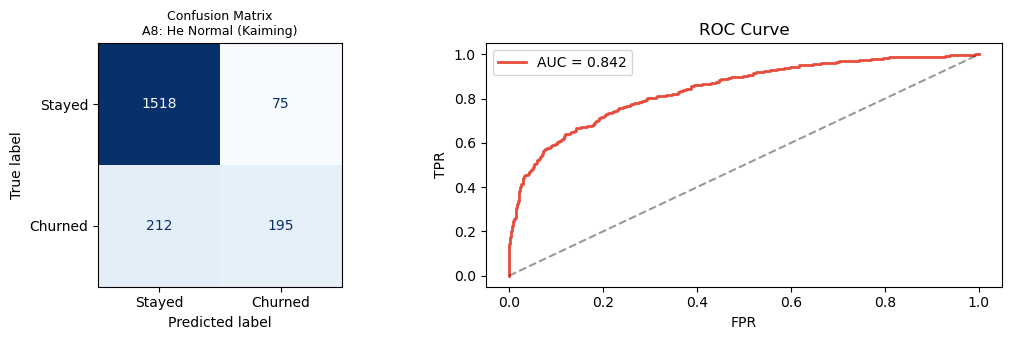


  Training: A9: He Uniform
    Best val_loss: 0.3419 at epoch 26


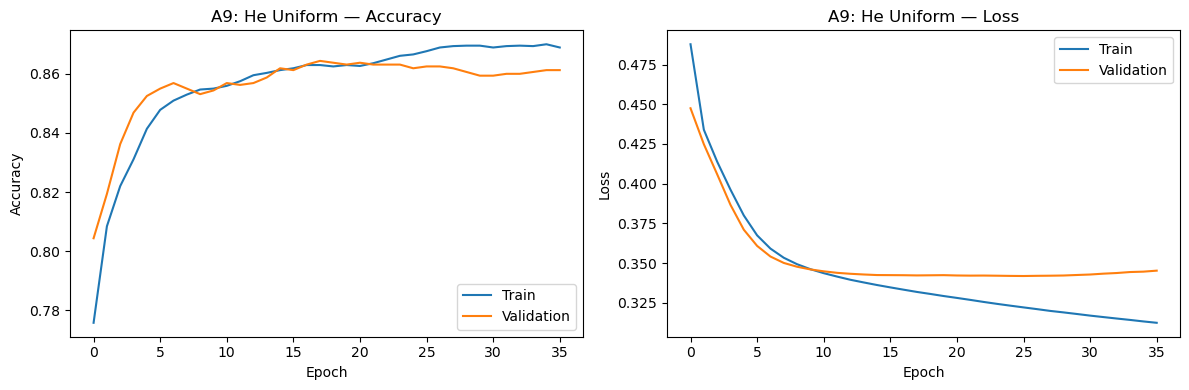


  A9: He Uniform
              precision    recall  f1-score   support

      Stayed       0.87      0.96      0.91      1593
     Churned       0.75      0.44      0.55       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC : 0.8427


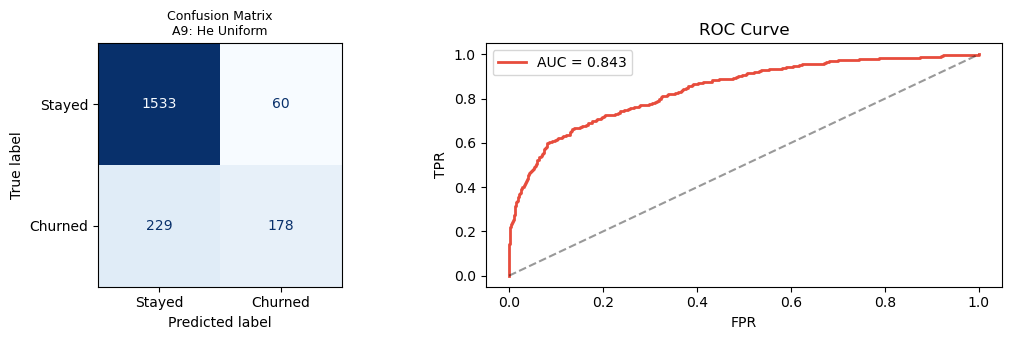


  Training: A10: Random Normal
    Best val_loss: 0.3255 at epoch 36


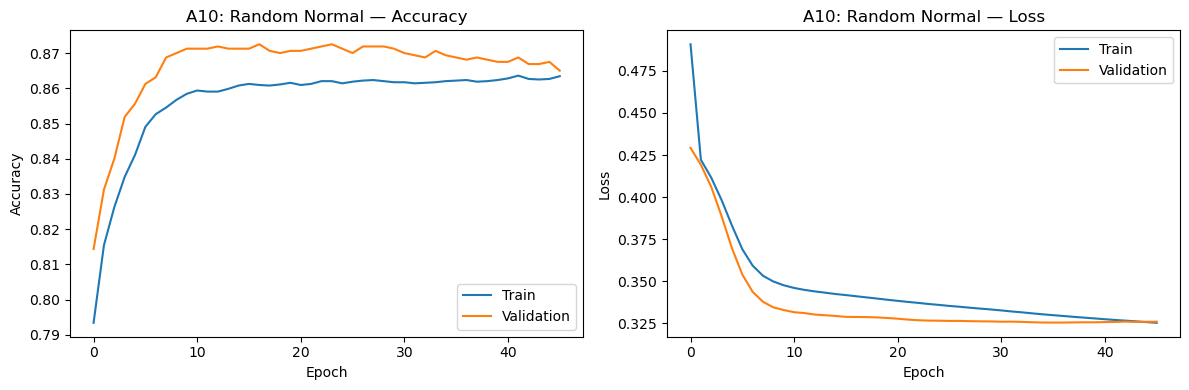


  A10: Random Normal
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

ROC-AUC : 0.8578


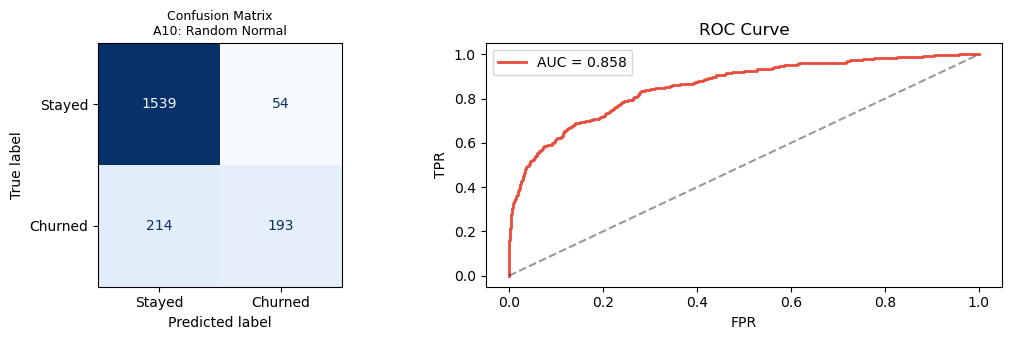


>>> A11: Keras Tuner — Phase A
Search space summary
Default search space size: 6
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
act_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lr (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}

✅ Phase A tuning complete!

=== Best Hyperparameters (Phase A) ===
  num_layers: 2
  units_0: 32
  act_0: tanh
  dropout_0: 0.4
  lr: 0.001
  optimizer: adam
  units_1: 64
  act_1: relu
  dropout_1: 0.2


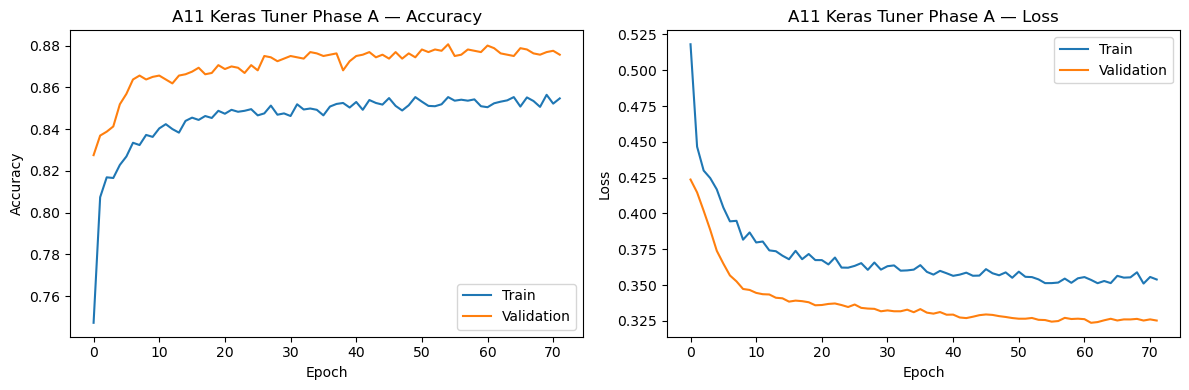


  A11: Keras Tuner (Phase A)
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.79      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000

ROC-AUC : 0.8662


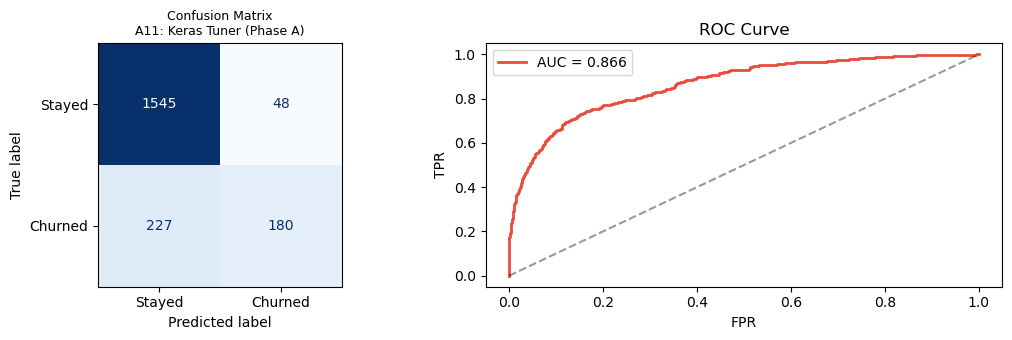


SECTION 5 — PHASE B: WITH IMBALANCE HANDLING
NOTE: SMOTE + Class Weight combined is EXCLUDED (per requirements).

Computed class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}

=== Class Counts After Resampling ===
  Original       : {np.int64(0): np.int64(6370), np.int64(1): np.int64(1630)}
  SMOTE          : {np.int64(0): np.int64(6370), np.int64(1): np.int64(6370)}
  RandomOver     : {np.int64(0): np.int64(6370), np.int64(1): np.int64(6370)}
  RandomUnder    : {np.int64(0): np.int64(1630), np.int64(1): np.int64(1630)}
  SMOTEENN       : {np.int64(0): np.int64(4163), np.int64(1): np.int64(5413)}


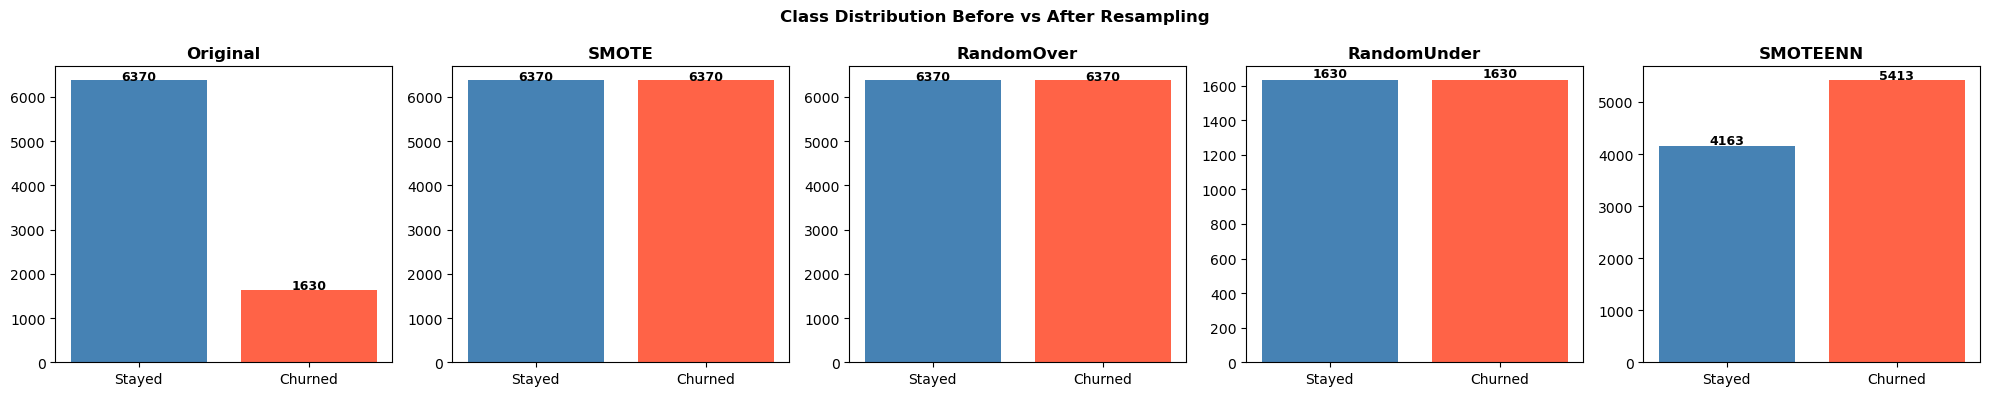


>>> B1: Class Weights  (train size: 8000)


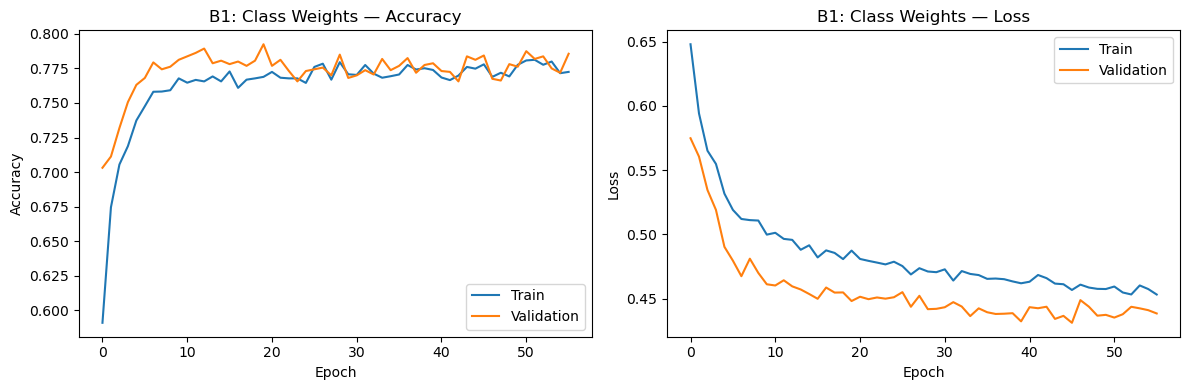


  B1: Class Weights
              precision    recall  f1-score   support

      Stayed       0.93      0.78      0.85      1593
     Churned       0.48      0.78      0.59       407

    accuracy                           0.78      2000
   macro avg       0.71      0.78      0.72      2000
weighted avg       0.84      0.78      0.80      2000

ROC-AUC : 0.8558


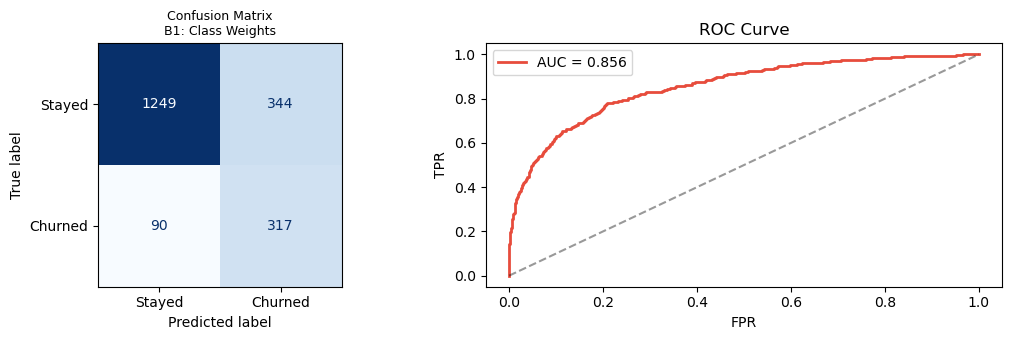


>>> B2: SMOTE  (train size: 12740)


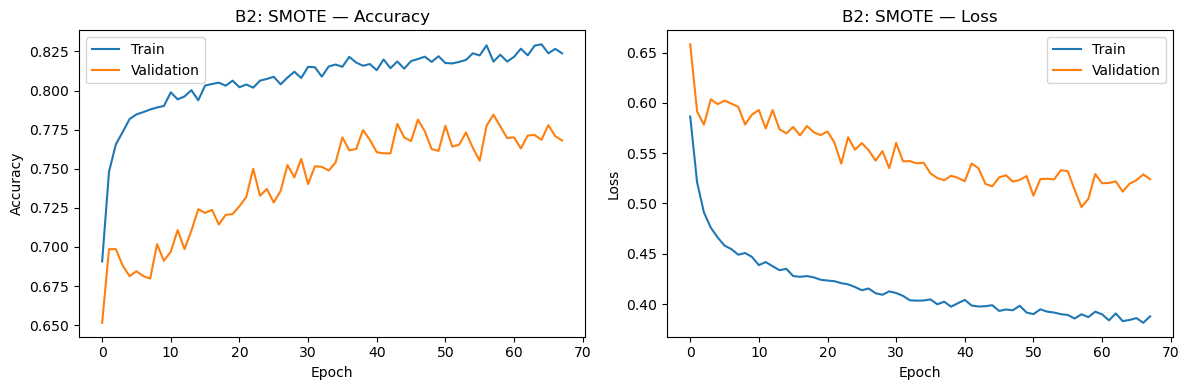


  B2: SMOTE
              precision    recall  f1-score   support

      Stayed       0.91      0.87      0.89      1593
     Churned       0.56      0.67      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.83      2000

ROC-AUC : 0.8549


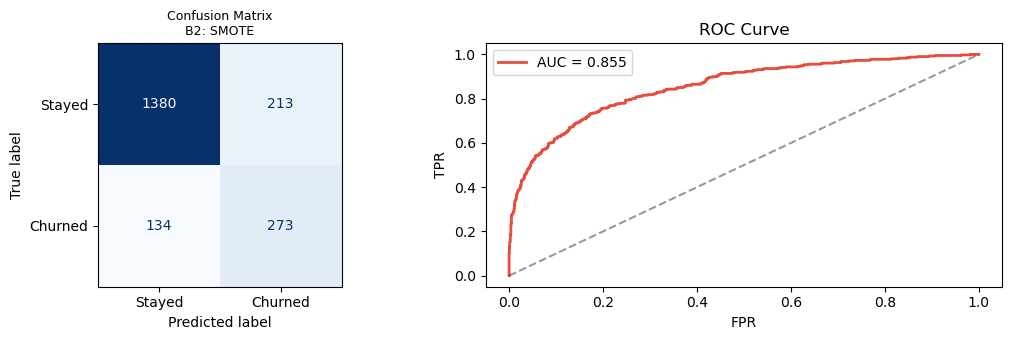


>>> B3: Random Oversampling  (train size: 12740)


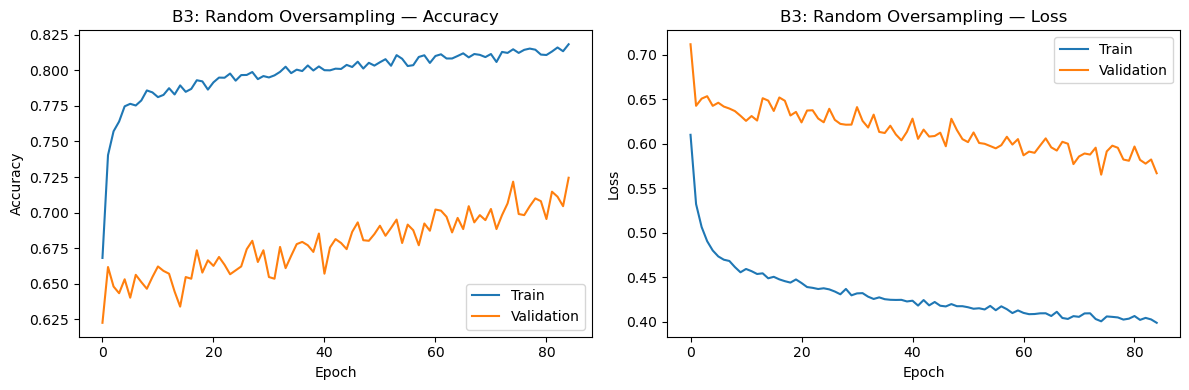


  B3: Random Oversampling
              precision    recall  f1-score   support

      Stayed       0.91      0.88      0.89      1593
     Churned       0.58      0.65      0.62       407

    accuracy                           0.83      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.83      0.84      2000

ROC-AUC : 0.8530


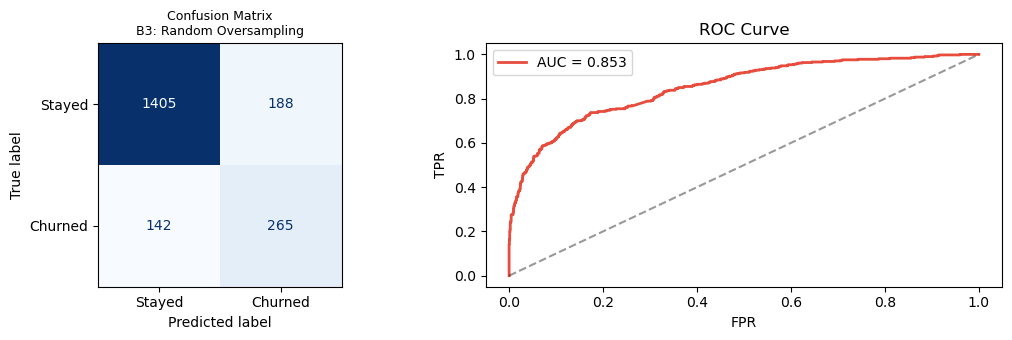


>>> B4: Random Undersampling  (train size: 3260)


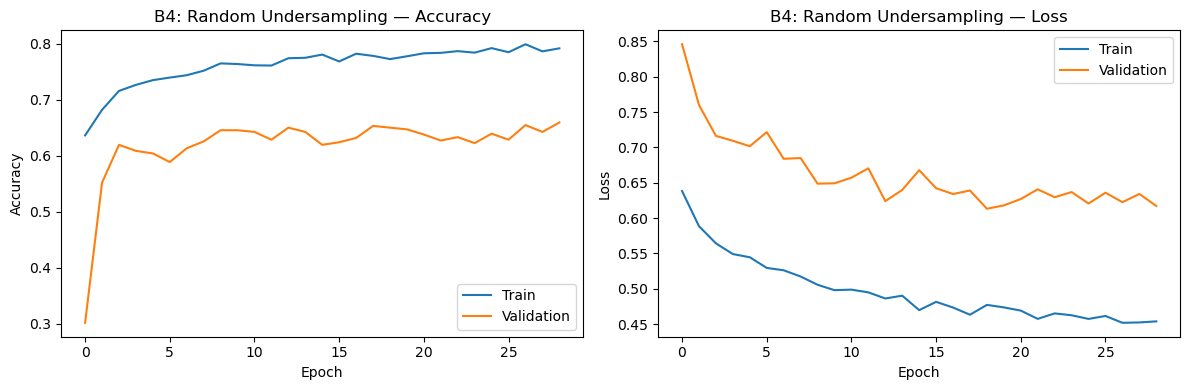


  B4: Random Undersampling
              precision    recall  f1-score   support

      Stayed       0.91      0.87      0.89      1593
     Churned       0.57      0.65      0.61       407

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.83      2000

ROC-AUC : 0.8513


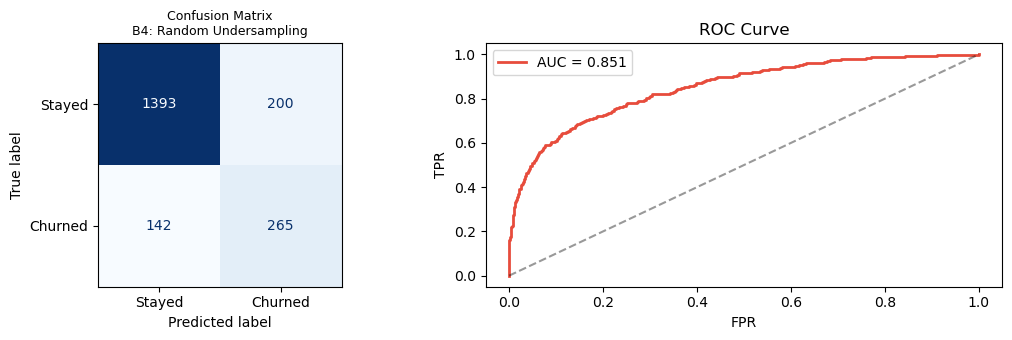


>>> B5: SMOTEENN  (train size: 9576)


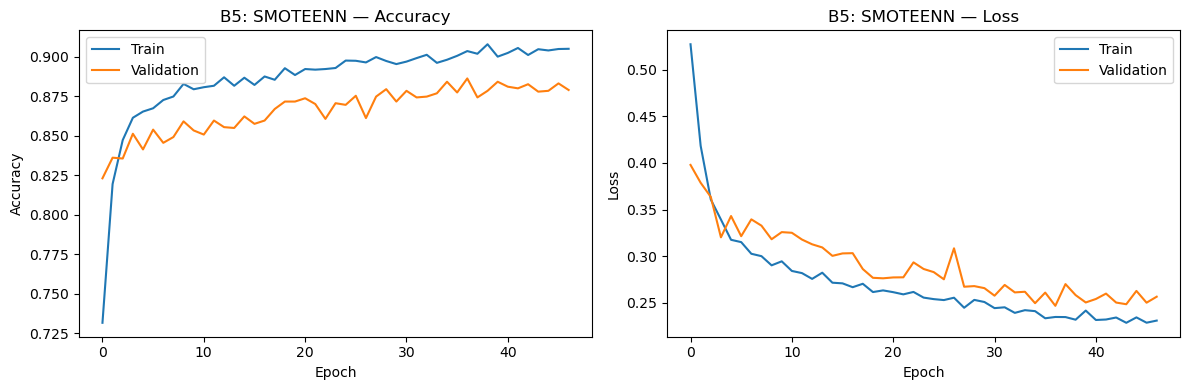


  B5: SMOTEENN
              precision    recall  f1-score   support

      Stayed       0.93      0.77      0.84      1593
     Churned       0.46      0.78      0.58       407

    accuracy                           0.77      2000
   macro avg       0.70      0.77      0.71      2000
weighted avg       0.84      0.77      0.79      2000

ROC-AUC : 0.8499


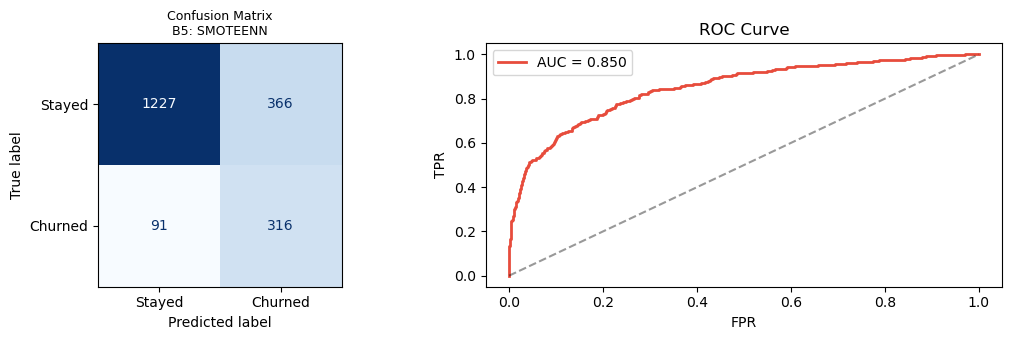


>>> B6: Keras Tuner — Phase B
Best Phase B so far: B1: Class Weights
✅ Phase B tuning complete!

=== Best Hyperparameters (Phase B) ===
  num_layers: 3
  units_0: 64
  act_0: relu
  dropout_0: 0.0
  lr: 0.001
  optimizer: rmsprop
  units_1: 128
  act_1: relu
  dropout_1: 0.0
  units_2: 16
  act_2: tanh
  dropout_2: 0.4


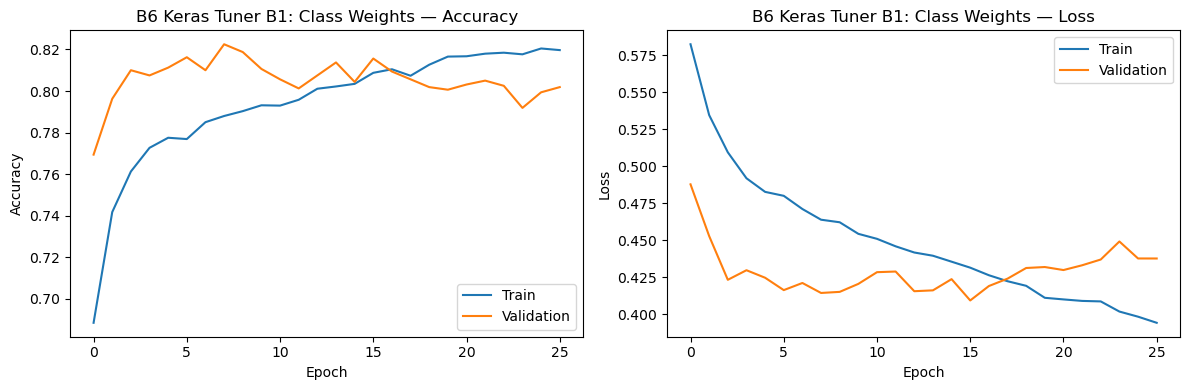


  B6: Keras Tuner (B1: Class Weights)
              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.89      1593
     Churned       0.56      0.68      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC : 0.8513


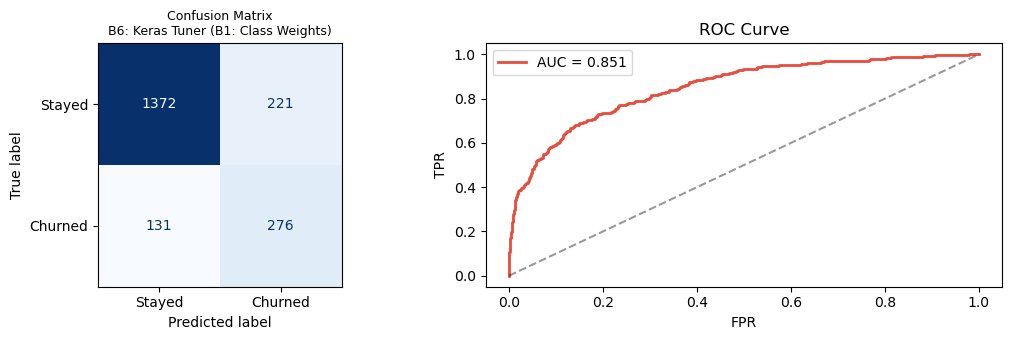


SECTION 6 — SAVE ALL MODELS & LOAD + RE-VERIFY

Saving all models…
  ✅ A1_BatchGD_SGD                 → saved_models/A1_BatchGD_SGD.keras  (24.8 KB)
  ✅ A2_StochasticGD_SGD            → saved_models/A2_StochasticGD_SGD.keras  (24.8 KB)
  ✅ A3_Adam                        → saved_models/A3_Adam.keras  (35.8 KB)
  ✅ A4_RMSprop                     → saved_models/A4_RMSprop.keras  (30.1 KB)
  ✅ A5_EarlyStopping               → saved_models/A5_EarlyStopping.keras  (35.8 KB)
  ✅ A6_Dropout                     → saved_models/A6_Dropout.keras  (62.9 KB)
  ✅ A7_GlorotUniform               → saved_models/A7_GlorotUniform.keras  (35.8 KB)
  ✅ A8_HeNormal                    → saved_models/A8_HeNormal.keras  (35.8 KB)
  ✅ A9_HeUniform                   → saved_models/A9_HeUniform.keras  (35.8 KB)
  ✅ A10_RandomNormal               → saved_models/A10_RandomNormal.keras  (35.9 KB)
  ✅ A11_KerasTuner                 → saved_models/A11_KerasTuner.keras  (59.2 KB)
  ✅ B1_ClassWeights                → sa

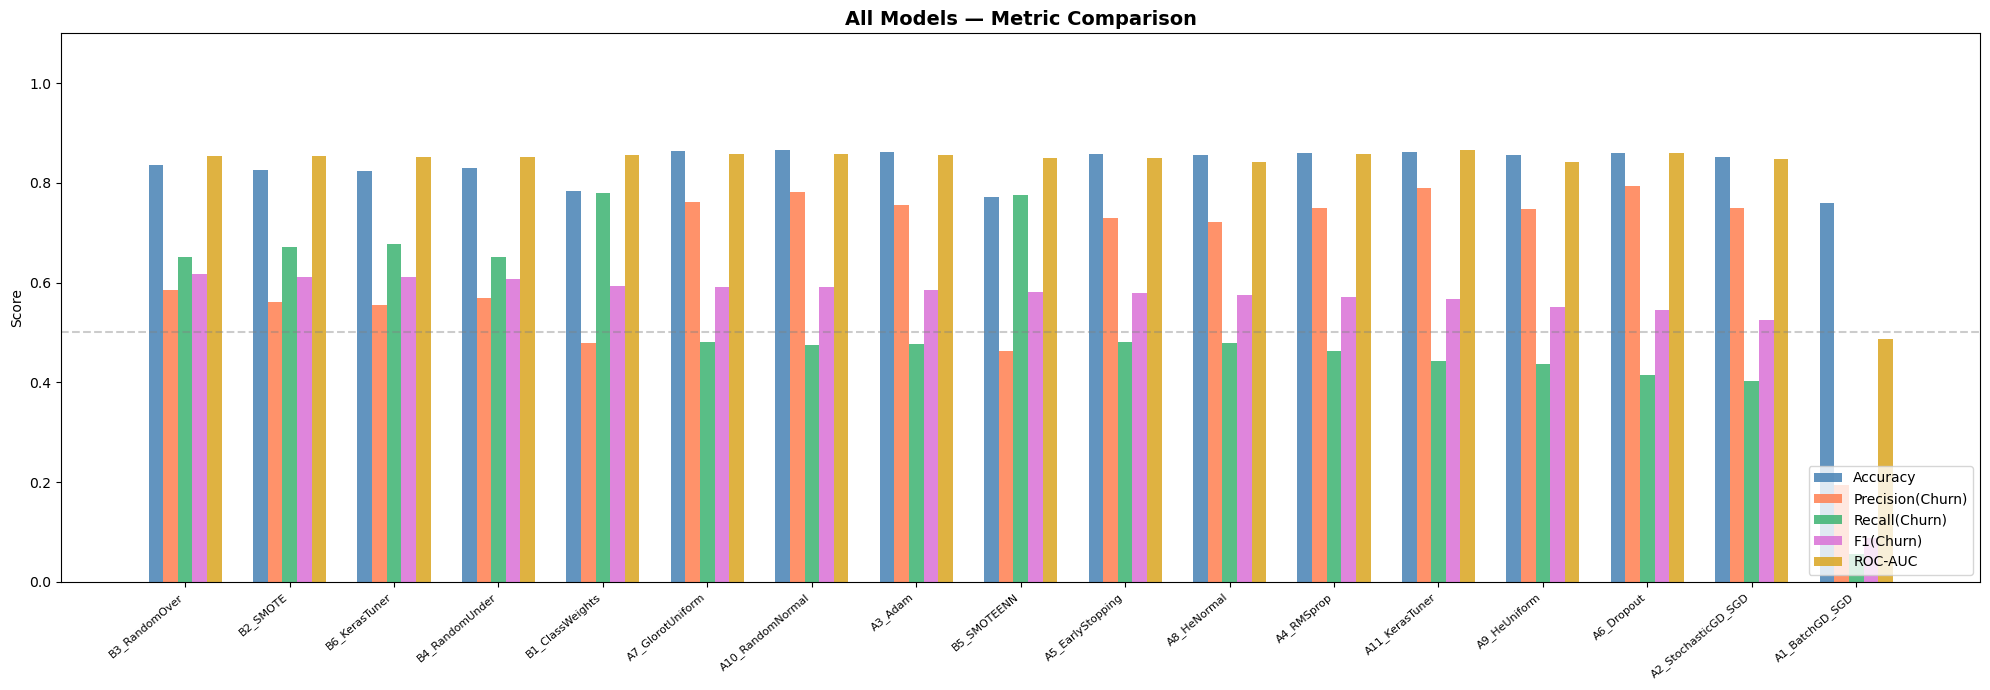

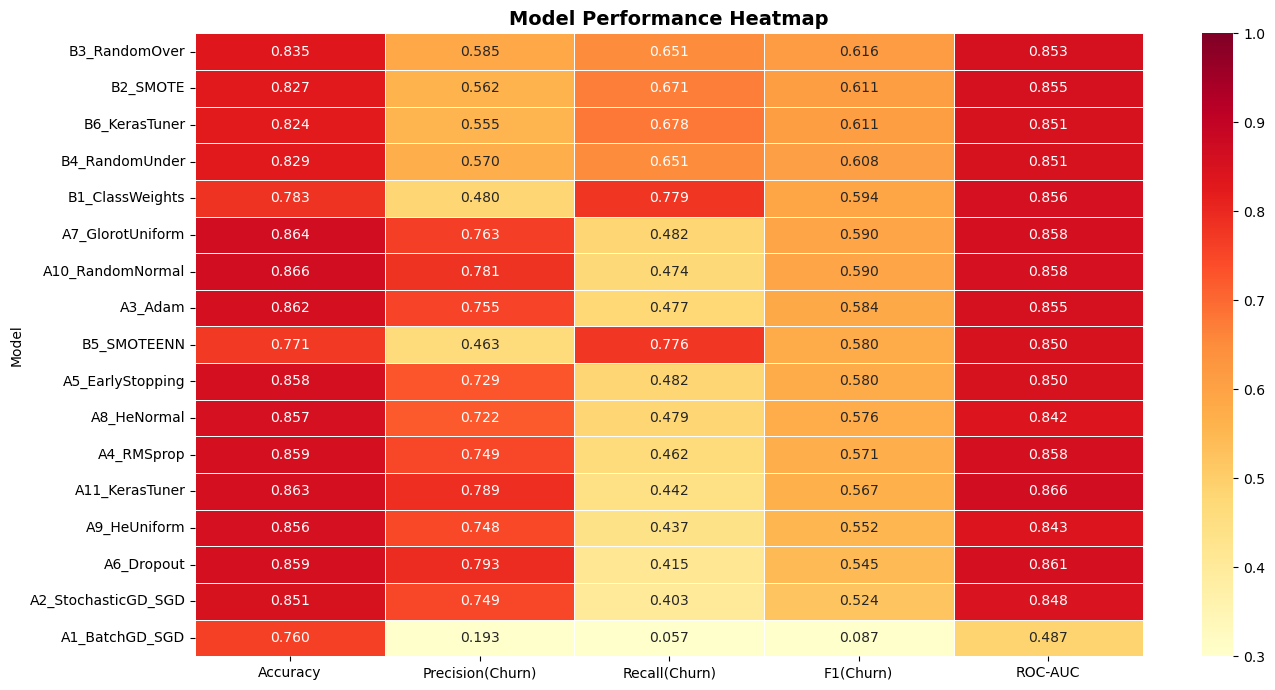

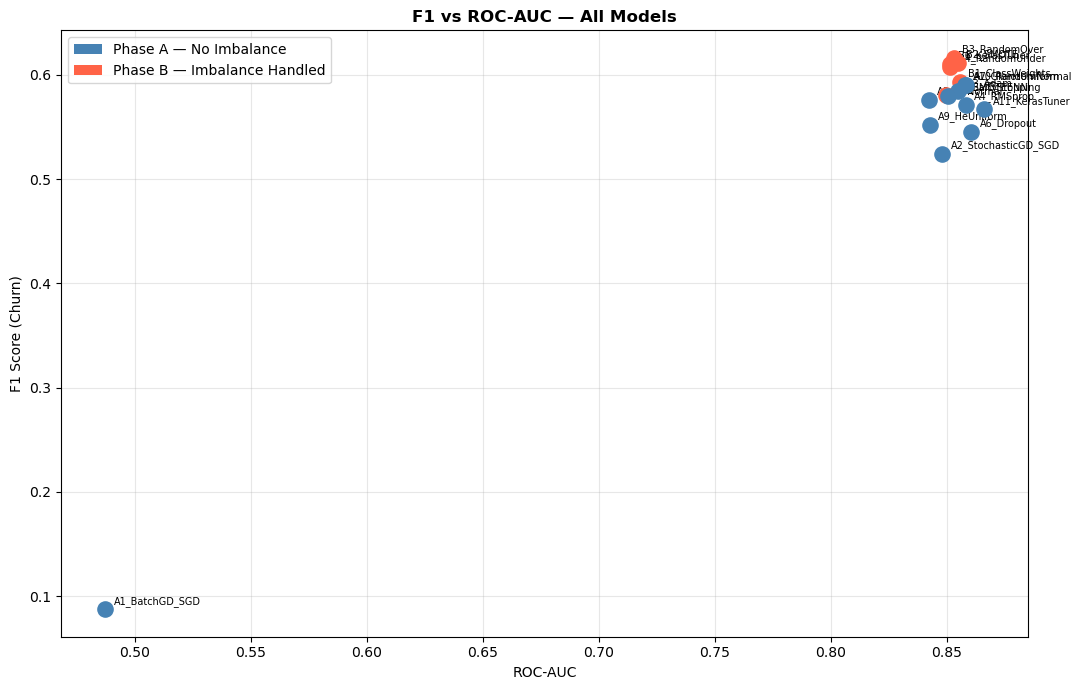

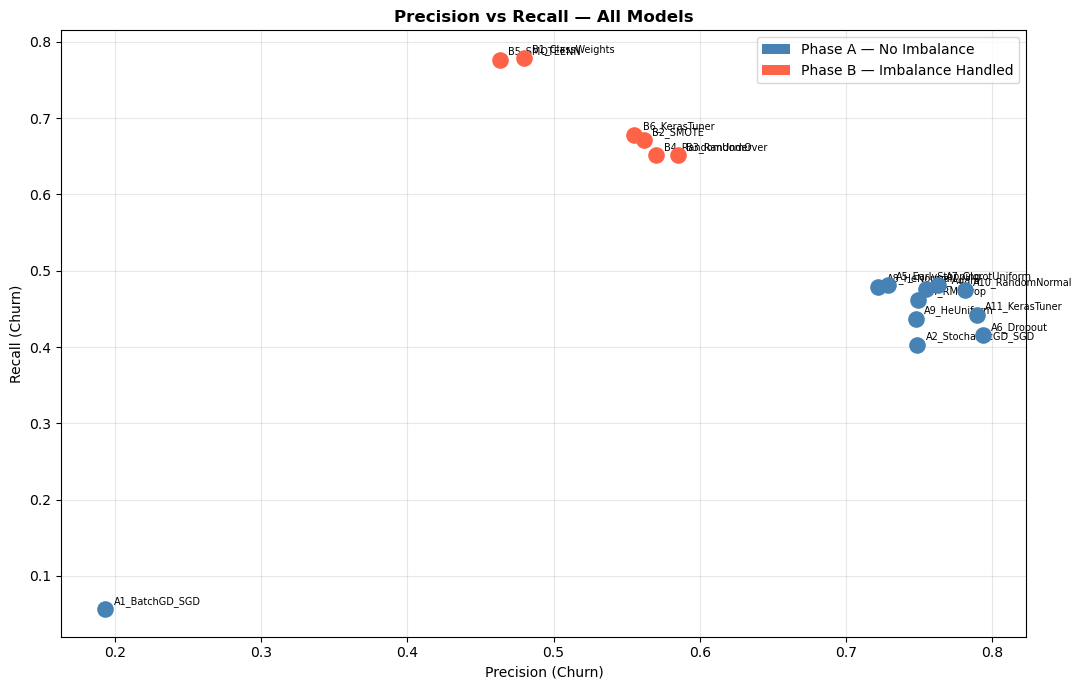

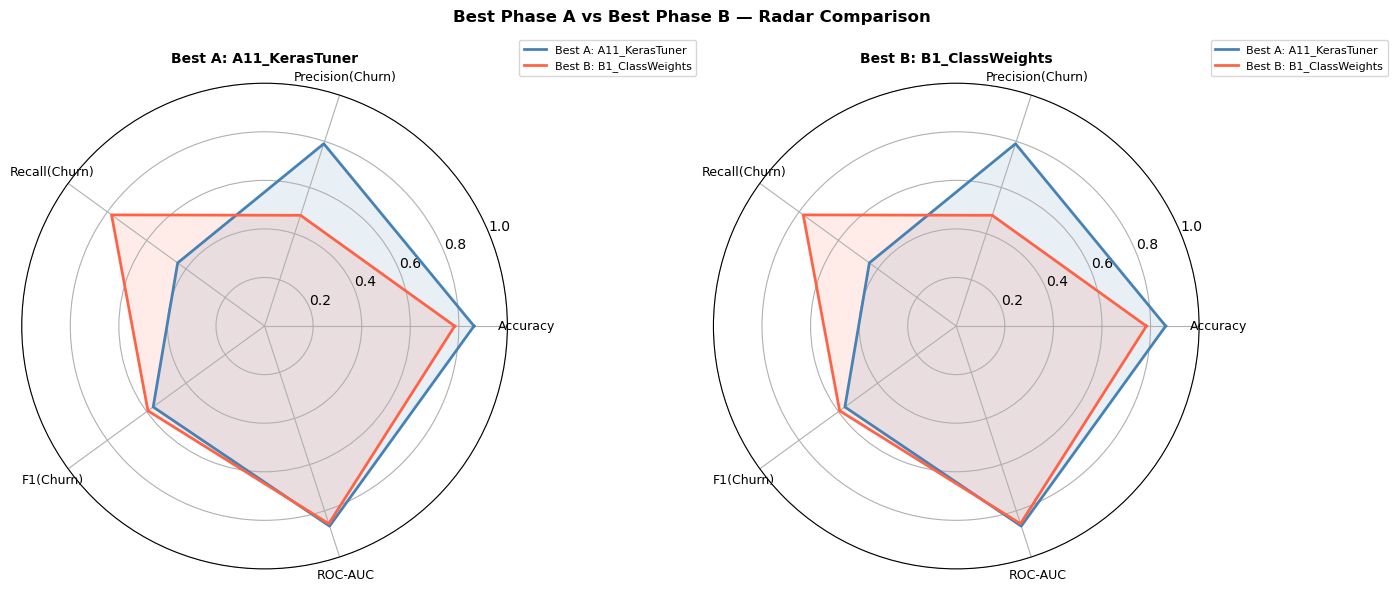


PHASE A — RANKED BY ROC-AUC
              Model  Accuracy  Recall(Churn)  F1(Churn)  ROC-AUC
     A11_KerasTuner    0.8625         0.4423     0.5669   0.8662
         A6_Dropout    0.8590         0.4152     0.5452   0.8607
   A7_GlorotUniform    0.8640         0.4816     0.5904   0.8584
         A4_RMSprop    0.8590         0.4619     0.5714   0.8583
   A10_RandomNormal    0.8660         0.4742     0.5902   0.8578
            A3_Adam    0.8620         0.4767     0.5843   0.8550
   A5_EarlyStopping    0.8580         0.4816     0.5799   0.8504
A2_StochasticGD_SGD    0.8510         0.4029     0.5240   0.8482
       A9_HeUniform    0.8555         0.4373     0.5519   0.8427
        A8_HeNormal    0.8565         0.4791     0.5761   0.8424
     A1_BatchGD_SGD    0.7600         0.0565     0.0875   0.4873

PHASE B — RANKED BY ROC-AUC
          Model  Accuracy  Recall(Churn)  F1(Churn)  ROC-AUC
B1_ClassWeights    0.7830         0.7789     0.5936   0.8558
       B2_SMOTE    0.8265         0.6708

In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════╗
║       ANN CHURN MODELLING — Complete Deep Learning Pipeline             ║
║       Dataset  : Churn_Modeling.csv                                     ║
║       Sections : EDA → Preprocessing → Phase A (No Imbalance)          ║
║                  → Phase B (Imbalance Handling) → Keras Tuner           ║
║                  → Save/Load → Grand Comparison                         ║
╚══════════════════════════════════════════════════════════════════════════╝

MODELS TRAINED
──────────────────────────────────────────────────────────────────
PHASE A — Without Imbalance Handling
  A1  : Baseline ANN   (SGD  — Batch GD, large batch)
  A2  : Baseline ANN   (SGD  — Stochastic GD, batch=1)
  A3  : Baseline ANN   (Adam — Mini-Batch GD)          ← checkpoint
  A4  : Baseline ANN   (RMSprop — Mini-Batch GD)       ← checkpoint
  A5  : ANN + Early Stopping (patience=10)             ← checkpoint
  A6  : ANN + Dropout (0.3 / 0.2)                      ← checkpoint
  A7  : Weight Init — Glorot Uniform (Xavier)          ← checkpoint
  A8  : Weight Init — He Normal                        ← checkpoint
  A9  : Weight Init — He Uniform                       ← checkpoint
  A10 : Weight Init — Random Normal                    ← checkpoint
  A11 : Keras Tuner — Best Model (Phase A)             ← checkpoint

PHASE B — With Imbalance Handling
  B1  : Class Weights                                  ← checkpoint
  B2  : SMOTE                                          ← checkpoint
  B3  : Random Oversampling                            ← checkpoint
  B4  : Random Undersampling                           ← checkpoint
  B5  : SMOTEENN                                       ← checkpoint
  B6  : Keras Tuner — Best Model (Phase B)             ← checkpoint


──────────────────────────────────────────────────────────────────
"""

# ──────────────────────────────────────────────────────────────────
# SECTION 0 — IMPORTS
# ──────────────────────────────────────────────────────────────────
import os
import math
import pickle
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import initializers
import keras_tuner as kt

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
warnings.filterwarnings("ignore")

os.makedirs("saved_models", exist_ok=True)

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras Tuner : {kt.__version__}")
print("saved_models/ directory ready\n")


# ──────────────────────────────────────────────────────────────────
# SECTION 1 — LOAD DATA & EDA
# ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 1 — LOAD DATA & EDA")
print("=" * 60)

df = pd.read_csv("Churn_Modeling.csv")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

print("=== Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
print(df.describe().round(2))

# Target distribution
counts = df["Exited"].value_counts()
print("\n=== Target Variable (Exited) ===")
print(counts)
print(f"Churn Rate: {df['Exited'].mean() * 100:.1f}%")
print("⚠️  Dataset is IMBALANCED — ~80% stayed, ~20% churned.")

# ── EDA Plots ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Class distribution
axes[0, 0].bar(["Stayed (0)", "Churned (1)"], counts.values,
               color=["steelblue", "tomato"])
axes[0, 0].set_title("Target Distribution")
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# 2. Churn by Geography
geo_churn = df.groupby("Geography")["Exited"].mean() * 100
axes[0, 1].bar(geo_churn.index, geo_churn.values,
               color=["#e74c3c", "#f39c12", "#27ae60"])
axes[0, 1].set_title("Churn Rate by Geography (%)")
for i, v in enumerate(geo_churn.values):
    axes[0, 1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# 3. Churn by Gender
gen_churn = df.groupby("Gender")["Exited"].mean() * 100
axes[0, 2].bar(gen_churn.index, gen_churn.values, color=["#3498db", "#e91e63"])
axes[0, 2].set_title("Churn Rate by Gender (%)")
for i, v in enumerate(gen_churn.values):
    axes[0, 2].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

# 4. Age distribution
df[df["Exited"] == 0]["Age"].hist(bins=30, alpha=0.7, label="Stayed",
                                  color="steelblue", ax=axes[1, 0])
df[df["Exited"] == 1]["Age"].hist(bins=30, alpha=0.7, label="Churned",
                                  color="tomato", ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution by Churn")
axes[1, 0].legend()

# 5. Balance distribution
df[df["Exited"] == 0]["Balance"].hist(bins=30, alpha=0.7, label="Stayed",
                                      color="steelblue", ax=axes[1, 1])
df[df["Exited"] == 1]["Balance"].hist(bins=30, alpha=0.7, label="Churned",
                                      color="tomato", ax=axes[1, 1])
axes[1, 1].set_title("Balance Distribution by Churn")
axes[1, 1].legend()

# 6. NumOfProducts vs Churn
sns.countplot(x="NumOfProducts", hue="Exited", data=df,
              palette=["steelblue", "tomato"], ax=axes[1, 2])
axes[1, 2].set_title("Num Products vs Churn")
axes[1, 2].legend(["Stayed", "Churned"])

plt.suptitle("EDA Dashboard — Bank Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 7))
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="RdYlBu_r", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ EDA plots saved.\n")


# ──────────────────────────────────────────────────────────────────
# SECTION 2 — PREPROCESSING
# ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 2 — PREPROCESSING")
print("=" * 60)

# Drop non-predictive columns, rename target
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
df.rename(columns={"Exited": "Churn"}, inplace=True)

# Skewness check & log1p transform
feature_cols = df.select_dtypes(include="number").drop("Churn", axis=1).columns
skewness = df[feature_cols].skew()
print("=== Skewness ===\n", skewness)

skewed_cols = skewness[abs(skewness) > 1].index.tolist()
for col in skewed_cols:
    df[col] = np.log1p(df[col])
print(f"\nlog1p applied to: {skewed_cols}")

# Encoding
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
print(f"Columns after encoding: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

# IQR outlier capping
def cap_outliers(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    data[col] = data[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return data

for col in ["CreditScore", "Age", "Balance", "EstimatedSalary"]:
    df = cap_outliers(df, col)
print("✅ Outlier capping done")

# Train/Test Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {X_train_raw.shape[0]}  |  Test: {X_test_raw.shape[0]}")
print(f"Train class dist: {dict(y_train_raw.value_counts())}")

# Scaling — fit ONLY on train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

# Save scaler for re-use
with open("saved_models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved to saved_models/scaler.pkl\n")


# ──────────────────────────────────────────────────────────────────
# SECTION 3 — HELPER FUNCTIONS
# ──────────────────────────────────────────────────────────────────
all_results = []   # Collects metrics from every model


def plot_history(history, title):
    """Plot training/validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(history.history[metric],           label="Train")
        ax.plot(history.history[f"val_{metric}"],  label="Validation")
        ax.set_title(f"{title} — {metric.capitalize()}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.capitalize())
        ax.legend()
    plt.tight_layout()
    plt.savefig(f"plot_{title.replace(' ', '_').replace(':', '')}.png",
                dpi=100, bbox_inches="tight")
    plt.show()


def evaluate_model(model, label):
    """Predict, print classification report + ROC curve, save results."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    report  = classification_report(y_test, y_pred,
                                    output_dict=True, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'=' * 55}\n  {label}\n{'=' * 55}")
    print(classification_report(y_test, y_pred, zero_division=0,
                                 target_names=["Stayed", "Churned"]))
    print(f"ROC-AUC : {roc_auc:.4f}")

    # Confusion matrix + ROC curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=["Stayed", "Churned"]
    ).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"Confusion Matrix\n{label}", fontsize=9)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color="#e74c3c", lw=2,
                 label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].set_title("ROC Curve"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"eval_{label.replace(' ', '_').replace(':', '')}.png",
                dpi=100, bbox_inches="tight")
    plt.show()

    all_results.append({
        "Model"            : label,
        "Accuracy"         : round(report["accuracy"], 4),
        "Precision(Churn)" : round(report["1"]["precision"], 4),
        "Recall(Churn)"    : round(report["1"]["recall"], 4),
        "F1(Churn)"        : round(report["1"]["f1-score"], 4),
        "ROC-AUC"          : round(roc_auc, 4),
    })

print("✅ Helper functions ready.\n")


# ──────────────────────────────────────────────────────────────────
# SECTION 4 — PHASE A: WITHOUT IMBALANCE HANDLING
# ──────────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 4 — PHASE A: WITHOUT IMBALANCE HANDLING")
print("=" * 60)


# ── Base architecture factory ──────────────────────────────────────
def build_base_ann(optimizer="adam", kernel_init="glorot_uniform",
                   dropout_rates=None):
    """
    2-hidden-layer ANN.
    dropout_rates : e.g. [0.3, 0.2]  — adds Dropout after each hidden layer
    """
    layers = [Input(shape=(X_train.shape[1],))]
    layers.append(Dense(32, activation="relu",
                        kernel_initializer=kernel_init))
    if dropout_rates:
        layers.append(Dropout(dropout_rates[0]))
    layers.append(Dense(16, activation="relu",
                        kernel_initializer=kernel_init))
    if dropout_rates:
        layers.append(Dropout(dropout_rates[1]))
    layers.append(Dense(1, activation="sigmoid"))

    model = Sequential(layers)
    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


# ─────────────────────────────────────────────────────────────────
# A1 — Batch GD (SGD, full-dataset batch)
# ─────────────────────────────────────────────────────────────────
print("\n>>> A1: Batch GD (SGD, batch=full dataset)")
model_a1 = build_base_ann(optimizer="sgd")
hist_a1 = model_a1.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=50,
    batch_size=len(X_train),    # Batch GD = full dataset per step
    verbose=0
)
plot_history(hist_a1, "A1 Batch GD SGD")
evaluate_model(model_a1, "A1: Batch GD (SGD)")


# ─────────────────────────────────────────────────────────────────
# A2 — Stochastic GD (SGD, batch=1)
# ─────────────────────────────────────────────────────────────────
print("\n>>> A2: Stochastic GD (SGD, batch=1) — 20 epochs (slow by design)")
model_a2 = build_base_ann(optimizer="sgd")
hist_a2 = model_a2.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=20,
    batch_size=1,               # Stochastic GD = 1 sample per step
    verbose=0
)
plot_history(hist_a2, "A2 Stochastic GD SGD")
evaluate_model(model_a2, "A2: Stochastic GD (SGD, batch=1)")


# ─────────────────────────────────────────────────────────────────
# A3 — Mini-Batch GD with Adam + ModelCheckpoint
# ─────────────────────────────────────────────────────────────────
print("\n>>> A3: Mini-Batch GD (Adam) + ModelCheckpoint")
model_a3 = build_base_ann(optimizer="adam")
ckpt_a3 = ModelCheckpoint(
    "saved_models/A3_Adam.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
hist_a3 = model_a3.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[ckpt_a3],
    verbose=0
)
plot_history(hist_a3, "A3 Mini-Batch Adam")
evaluate_model(model_a3, "A3: Mini-Batch GD (Adam)")


# ─────────────────────────────────────────────────────────────────
# A4 — Mini-Batch GD with RMSprop + ModelCheckpoint
# ─────────────────────────────────────────────────────────────────
print("\n>>> A4: Mini-Batch GD (RMSprop) + ModelCheckpoint")
model_a4 = build_base_ann(optimizer="rmsprop")
ckpt_a4 = ModelCheckpoint(
    "saved_models/A4_RMSprop.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
hist_a4 = model_a4.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[ckpt_a4],
    verbose=0
)
plot_history(hist_a4, "A4 Mini-Batch RMSprop")
evaluate_model(model_a4, "A4: Mini-Batch GD (RMSprop)")


# ─────────────────────────────────────────────────────────────────
# A5 — Early Stopping (patience=10) + ModelCheckpoint
# ─────────────────────────────────────────────────────────────────
print("\n>>> A5: Early Stopping (patience=10)")
model_a5 = build_base_ann(optimizer="adam")
es_a5 = EarlyStopping(
    monitor="val_loss", patience=10,
    restore_best_weights=True, verbose=1
)
ckpt_a5 = ModelCheckpoint(
    "saved_models/A5_EarlyStopping.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
hist_a5 = model_a5.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=200,                 # High max — early stopping decides
    batch_size=32,
    callbacks=[es_a5, ckpt_a5],
    verbose=0
)
print(f"  Stopped at epoch: {len(hist_a5.history['loss'])}")
plot_history(hist_a5, "A5 Early Stopping")
evaluate_model(model_a5, "A5: Early Stopping")


# ─────────────────────────────────────────────────────────────────
# A6 — Dropout Regularization + ModelCheckpoint
# ─────────────────────────────────────────────────────────────────
print("\n>>> A6: Dropout Regularization (0.3 + 0.2)")
model_a6 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.3),               # Drop 30% neurons
    Dense(32, activation="relu"),
    Dropout(0.2),               # Drop 20% neurons
    Dense(1, activation="sigmoid")
])
model_a6.compile(optimizer="adam", loss="binary_crossentropy",
                 metrics=["accuracy"])

ckpt_a6 = ModelCheckpoint(
    "saved_models/A6_Dropout.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
es_a6 = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
hist_a6 = model_a6.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[ckpt_a6, es_a6],
    verbose=0
)
plot_history(hist_a6, "A6 Dropout")
evaluate_model(model_a6, "A6: Dropout (0.3 + 0.2)")


# ─────────────────────────────────────────────────────────────────
# A7–A10 — Weight Initialization Techniques
# ─────────────────────────────────────────────────────────────────
print("\n>>> A7–A10: Weight Initialization Techniques")

weight_init_configs = [
    ("glorot_uniform", "A7: Glorot Uniform (Xavier)"),  # Good for tanh/sigmoid
    ("he_normal",      "A8: He Normal (Kaiming)"),       # Best for ReLU
    ("he_uniform",     "A9: He Uniform"),
    ("random_normal",  "A10: Random Normal"),
]

init_models = {}
for init_name, label in weight_init_configs:
    print(f"\n  Training: {label}")
    m = build_base_ann(optimizer="adam", kernel_init=init_name)
    safe_name = label.split(":")[0].strip().replace(" ", "_")
    ckpt = ModelCheckpoint(
        f"saved_models/{safe_name}.keras",
        monitor="val_loss", save_best_only=True, mode="min", verbose=0
    )
    es = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
    h = m.fit(
        X_train, y_train_raw,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[ckpt, es],
        verbose=0
    )
    best_val = min(h.history["val_loss"])
    best_ep  = np.argmin(h.history["val_loss"]) + 1
    print(f"    Best val_loss: {best_val:.4f} at epoch {best_ep}")
    plot_history(h, label)
    evaluate_model(m, label)
    init_models[label] = m


# ─────────────────────────────────────────────────────────────────
# A11 — Keras Tuner (Phase A)
# ─────────────────────────────────────────────────────────────────
print("\n>>> A11: Keras Tuner — Phase A")


def build_tunable_model_a(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(Dense(
            units=hp.Choice(f"units_{i}", [16, 32, 64, 128]),
            activation=hp.Choice(f"act_{i}", ["relu", "tanh"])
        ))
        model.add(Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)))
    model.add(Dense(1, activation="sigmoid"))
    lr  = hp.Choice("lr", [0.001, 0.0005, 0.0001])
    opt = hp.Choice("optimizer", ["adam", "rmsprop"])
    model.compile(
        optimizer=(tf.keras.optimizers.Adam(lr)
                   if opt == "adam" else tf.keras.optimizers.RMSprop(lr)),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


tuner_a = kt.RandomSearch(
    build_tunable_model_a,
    objective="val_accuracy",
    max_trials=15,
    seed=SEED,
    overwrite=True,
    directory="kt_phase_a",
    project_name="churn_phase_a"
)
tuner_a.search_space_summary()

tuner_a.search(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8)],
    verbose=0
)
print("✅ Phase A tuning complete!")

best_hp_a = tuner_a.get_best_hyperparameters(1)[0]
print("\n=== Best Hyperparameters (Phase A) ===")
for k, v in best_hp_a.values.items():
    print(f"  {k}: {v}")

model_a11 = tuner_a.hypermodel.build(best_hp_a)
ckpt_a11 = ModelCheckpoint(
    "saved_models/A11_KerasTuner.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
es_a11 = EarlyStopping(monitor="val_loss", patience=10,
                        restore_best_weights=True)
hist_a11 = model_a11.fit(
    X_train, y_train_raw,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[ckpt_a11, es_a11],
    verbose=0
)
plot_history(hist_a11, "A11 Keras Tuner Phase A")
evaluate_model(model_a11, "A11: Keras Tuner (Phase A)")


# ──────────────────────────────────────────────────────────────────
# SECTION 5 — PHASE B: WITH IMBALANCE HANDLING
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5 — PHASE B: WITH IMBALANCE HANDLING")
print("=" * 60)
print("NOTE: SMOTE + Class Weight combined is EXCLUDED (per requirements).\n")

# ── Class weights ──────────────────────────────────────────────────
cw_arr = compute_class_weight("balanced",
                               classes=np.unique(y_train_raw),
                               y=y_train_raw)
class_weight_dict = dict(enumerate(cw_arr))
print(f"Computed class weights: {class_weight_dict}")

# ── Resampled datasets ─────────────────────────────────────────────
X_tr_smote,    y_tr_smote    = SMOTE(random_state=SEED).fit_resample(X_train, y_train_raw)
X_tr_ros,      y_tr_ros      = RandomOverSampler(random_state=SEED).fit_resample(X_train, y_train_raw)
X_tr_rus,      y_tr_rus      = RandomUnderSampler(random_state=SEED).fit_resample(X_train, y_train_raw)
X_tr_smoteenn, y_tr_smoteenn = SMOTEENN(random_state=SEED).fit_resample(X_train, y_train_raw)

print("\n=== Class Counts After Resampling ===")
for name, y_data in [
    ("Original",    y_train_raw),
    ("SMOTE",       y_tr_smote),
    ("RandomOver",  y_tr_ros),
    ("RandomUnder", y_tr_rus),
    ("SMOTEENN",    y_tr_smoteenn),
]:
    cnts = dict(zip(*np.unique(y_data, return_counts=True)))
    print(f"  {name:15s}: {cnts}")

# Visualise resampling
resample_info = {
    "Original":    y_train_raw,
    "SMOTE":       y_tr_smote,
    "RandomOver":  y_tr_ros,
    "RandomUnder": y_tr_rus,
    "SMOTEENN":    y_tr_smoteenn,
}
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, y_data) in zip(axes, resample_info.items()):
    cnts = pd.Series(y_data).value_counts().sort_index()
    ax.bar(["Stayed", "Churned"], cnts.values, color=["steelblue", "tomato"])
    ax.set_title(name, fontweight="bold")
    for j, v in enumerate(cnts.values):
        ax.text(j, v + 20, str(v), ha="center", fontsize=9, fontweight="bold")
plt.suptitle("Class Distribution Before vs After Resampling",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("resampling_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


# ── Phase B model factory ──────────────────────────────────────────
def build_ann_b(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


def train_phase_b(X_tr, y_tr, label, class_weight=None):
    """Train, checkpoint, plot, evaluate a Phase B model."""
    print(f"\n>>> {label}  (train size: {X_tr.shape[0]})")
    model = build_ann_b(X_tr.shape[1])
    safe  = label.replace(" ", "_").replace(":", "").replace("/", "")
    ckpt  = ModelCheckpoint(
        f"saved_models/{safe}.keras",
        monitor="val_loss", save_best_only=True, mode="min", verbose=0
    )
    es = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        class_weight=class_weight,
        callbacks=[ckpt, es],
        verbose=0
    )
    plot_history(history, label)
    evaluate_model(model, label)
    return model


# ─────────────────────────────────────────────────────────────────
# B1 — Class Weights
# ─────────────────────────────────────────────────────────────────
model_b1 = train_phase_b(
    X_train, y_train_raw,
    "B1: Class Weights",
    class_weight=class_weight_dict
)

# ─────────────────────────────────────────────────────────────────
# B2 — SMOTE
# ─────────────────────────────────────────────────────────────────
model_b2 = train_phase_b(X_tr_smote, y_tr_smote, "B2: SMOTE")

# ─────────────────────────────────────────────────────────────────
# B3 — Random Oversampling
# ─────────────────────────────────────────────────────────────────
model_b3 = train_phase_b(X_tr_ros, y_tr_ros, "B3: Random Oversampling")

# ─────────────────────────────────────────────────────────────────
# B4 — Random Undersampling
# ─────────────────────────────────────────────────────────────────
model_b4 = train_phase_b(X_tr_rus, y_tr_rus, "B4: Random Undersampling")

# ─────────────────────────────────────────────────────────────────
# B5 — SMOTEENN
# ─────────────────────────────────────────────────────────────────
model_b5 = train_phase_b(X_tr_smoteenn, y_tr_smoteenn, "B5: SMOTEENN")


# ─────────────────────────────────────────────────────────────────
# B6 — Keras Tuner on best Phase B technique
# ─────────────────────────────────────────────────────────────────
print("\n>>> B6: Keras Tuner — Phase B")

# Pick best Phase B technique by ROC-AUC (from results so far)
phase_b_results = [r for r in all_results if r["Model"].startswith("B")]
best_b_label = max(phase_b_results, key=lambda x: x["ROC-AUC"])["Model"]
print(f"Best Phase B so far: {best_b_label}")

data_map_b = {
    "B1: Class Weights"       : (X_train,       y_train_raw,  class_weight_dict),
    "B2: SMOTE"               : (X_tr_smote,    y_tr_smote,   None),
    "B3: Random Oversampling" : (X_tr_ros,       y_tr_ros,    None),
    "B4: Random Undersampling": (X_tr_rus,       y_tr_rus,    None),
    "B5: SMOTEENN"            : (X_tr_smoteenn, y_tr_smoteenn, None),
}
X_kt_b, y_kt_b, cw_kt_b = data_map_b[best_b_label]


def build_tunable_model_b(hp):
    model = Sequential()
    model.add(Input(shape=(X_kt_b.shape[1],)))
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(Dense(
            units=hp.Choice(f"units_{i}", [16, 32, 64, 128]),
            activation=hp.Choice(f"act_{i}", ["relu", "tanh"])
        ))
        model.add(Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)))
    model.add(Dense(1, activation="sigmoid"))
    lr  = hp.Choice("lr", [0.001, 0.0005, 0.0001])
    opt = hp.Choice("optimizer", ["adam", "rmsprop"])
    model.compile(
        optimizer=(tf.keras.optimizers.Adam(lr)
                   if opt == "adam" else tf.keras.optimizers.RMSprop(lr)),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


tuner_b = kt.RandomSearch(
    build_tunable_model_b,
    objective="val_accuracy",
    max_trials=15,
    seed=SEED,
    overwrite=True,
    directory="kt_phase_b",
    project_name="churn_phase_b"
)

tuner_b.search(
    X_kt_b, y_kt_b,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=cw_kt_b,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8)],
    verbose=0
)
print("✅ Phase B tuning complete!")

best_hp_b = tuner_b.get_best_hyperparameters(1)[0]
print("\n=== Best Hyperparameters (Phase B) ===")
for k, v in best_hp_b.values.items():
    print(f"  {k}: {v}")

model_b6 = tuner_b.hypermodel.build(best_hp_b)
ckpt_b6 = ModelCheckpoint(
    "saved_models/B6_KerasTuner.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0
)
es_b6 = EarlyStopping(monitor="val_loss", patience=10,
                       restore_best_weights=True)
hist_b6 = model_b6.fit(
    X_kt_b, y_kt_b,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=cw_kt_b,
    callbacks=[ckpt_b6, es_b6],
    verbose=0
)
plot_history(hist_b6, f"B6 Keras Tuner {best_b_label}")
evaluate_model(model_b6, f"B6: Keras Tuner ({best_b_label})")


# ──────────────────────────────────────────────────────────────────
# SECTION 6 — SAVE ALL MODELS & LOAD + RE-VERIFY
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 6 — SAVE ALL MODELS & LOAD + RE-VERIFY")
print("=" * 60)

model_registry = {
    "A1_BatchGD_SGD"      : model_a1,
    "A2_StochasticGD_SGD" : model_a2,
    "A3_Adam"             : model_a3,
    "A4_RMSprop"          : model_a4,
    "A5_EarlyStopping"    : model_a5,
    "A6_Dropout"          : model_a6,
    "A7_GlorotUniform"    : init_models["A7: Glorot Uniform (Xavier)"],
    "A8_HeNormal"         : init_models["A8: He Normal (Kaiming)"],
    "A9_HeUniform"        : init_models["A9: He Uniform"],
    "A10_RandomNormal"    : init_models["A10: Random Normal"],
    "A11_KerasTuner"      : model_a11,
    "B1_ClassWeights"     : model_b1,
    "B2_SMOTE"            : model_b2,
    "B3_RandomOver"       : model_b3,
    "B4_RandomUnder"      : model_b4,
    "B5_SMOTEENN"         : model_b5,
    "B6_KerasTuner"       : model_b6,
}

print("\nSaving all models…")
for name, model in model_registry.items():
    path = f"saved_models/{name}.keras"
    model.save(path)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✅ {name:30s} → {path}  ({size_kb:.1f} KB)")

# Save feature column names
with open("saved_models/feature_names.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)
print(f"\n✅ {len(model_registry)} models saved.")
print("✅ Feature names saved to saved_models/feature_names.pkl")

# ── Load & re-verify ───────────────────────────────────────────────
print("\nLoading all saved models and verifying…\n")
loaded_results = []

for name in model_registry.keys():
    path = f"saved_models/{name}.keras"
    loaded_model = load_model(path)
    y_prob = loaded_model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    report  = classification_report(y_test, y_pred,
                                    output_dict=True, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    loaded_results.append({
        "Model"            : name,
        "Accuracy"         : round(report["accuracy"], 4),
        "Precision(Churn)" : round(report["1"]["precision"], 4),
        "Recall(Churn)"    : round(report["1"]["recall"], 4),
        "F1(Churn)"        : round(report["1"]["f1-score"], 4),
        "ROC-AUC"          : round(roc_auc, 4),
    })
    print(f"  ✅ {name:30s} — ROC-AUC: {roc_auc:.4f}")

print("\n✅ All models loaded and verified!")
loaded_df = pd.DataFrame(loaded_results)
print("\n=== Verified Results from Loaded Models ===")
print(loaded_df.to_string(index=False))


# ──────────────────────────────────────────────────────────────────
# SECTION 7 — GRAND FINAL COMPARISON
# ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 7 — GRAND FINAL COMPARISON")
print("=" * 60)

metrics_final = ["Accuracy", "Precision(Churn)", "Recall(Churn)",
                 "F1(Churn)", "ROC-AUC"]

loaded_df["Phase"] = loaded_df["Model"].apply(
    lambda x: "A — No Imbalance" if x.startswith("A") else "B — Imbalance Handled"
)
loaded_df_sorted = loaded_df.sort_values("F1(Churn)", ascending=False).reset_index(drop=True)

print("\n=== ALL MODELS RANKED BY F1 (CHURN) ===")
print(loaded_df_sorted[["Model", "Accuracy", "Precision(Churn)",
                         "Recall(Churn)", "F1(Churn)", "ROC-AUC"]].to_string(index=False))

# ── 1. Grouped bar chart ──────────────────────────────────────────
n_models  = len(loaded_df_sorted)
n_metrics = len(metrics_final)
x = np.arange(n_models)
width = 0.14
colors = ["steelblue", "coral", "mediumseagreen", "orchid", "goldenrod"]

fig, ax = plt.subplots(figsize=(20, 7))
for i, (metric, color) in enumerate(zip(metrics_final, colors)):
    offset = (i - n_metrics / 2) * width + width / 2
    ax.bar(x + offset, loaded_df_sorted[metric],
           width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(loaded_df_sorted["Model"],
                   rotation=40, ha="right", fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("All Models — Metric Comparison", fontsize=14, fontweight="bold")
ax.axhline(0.5, linestyle="--", color="grey", alpha=0.4)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("grand_comparison_bar.png", dpi=130, bbox_inches="tight")
plt.show()

# ── 2. Heatmap ────────────────────────────────────────────────────
plt.figure(figsize=(14, 7))
heat_data = loaded_df_sorted.set_index("Model")[metrics_final]
sns.heatmap(heat_data, annot=True, fmt=".3f",
            cmap="YlOrRd", vmin=0.3, vmax=1.0, linewidths=0.5)
plt.title("Model Performance Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grand_comparison_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

# ── 3. F1 vs ROC-AUC scatter ──────────────────────────────────────
plt.figure(figsize=(11, 7))
for _, row in loaded_df_sorted.iterrows():
    color = "steelblue" if row["Model"].startswith("A") else "tomato"
    plt.scatter(row["ROC-AUC"], row["F1(Churn)"],
                s=120, zorder=5, color=color)
    plt.annotate(row["Model"],
                 (row["ROC-AUC"], row["F1(Churn)"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor="steelblue", label="Phase A — No Imbalance"),
              Patch(facecolor="tomato",    label="Phase B — Imbalance Handled")]
plt.legend(handles=legend_els)
plt.xlabel("ROC-AUC"); plt.ylabel("F1 Score (Churn)")
plt.title("F1 vs ROC-AUC — All Models", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("f1_vs_roc_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

# ── 4. Precision vs Recall scatter ───────────────────────────────
plt.figure(figsize=(11, 7))
for _, row in loaded_df_sorted.iterrows():
    color = "steelblue" if row["Model"].startswith("A") else "tomato"
    plt.scatter(row["Precision(Churn)"], row["Recall(Churn)"],
                s=120, zorder=5, color=color)
    plt.annotate(row["Model"],
                 (row["Precision(Churn)"], row["Recall(Churn)"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)
plt.legend(handles=legend_els)
plt.xlabel("Precision (Churn)"); plt.ylabel("Recall (Churn)")
plt.title("Precision vs Recall — All Models", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("precision_vs_recall_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

# ── 5. Radar chart: Best A vs Best B ──────────────────────────────
best_a = (loaded_df[loaded_df["Model"].str.startswith("A")]
          .sort_values("ROC-AUC", ascending=False).iloc[0])
best_b = (loaded_df[loaded_df["Model"].str.startswith("B")]
          .sort_values("ROC-AUC", ascending=False).iloc[0])

N = len(metrics_final)
angles = [n / float(N) * 2 * math.pi for n in range(N)] + [0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))
for ax, (label, row, color) in zip(axes, [
    (f"Best A: {best_a['Model']}", best_a, "steelblue"),
    (f"Best B: {best_b['Model']}", best_b, "tomato")
]):
    for (comp_label, comp_row, comp_color) in [
        (f"Best A: {best_a['Model']}", best_a, "steelblue"),
        (f"Best B: {best_b['Model']}", best_b, "tomato")
    ]:
        vals = [comp_row[m] for m in metrics_final] + [comp_row[metrics_final[0]]]
        ax.plot(angles, vals, linewidth=2, label=comp_label, color=comp_color)
        ax.fill(angles, vals, alpha=0.12, color=comp_color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_final, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=10, fontweight="bold", pad=15)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

plt.suptitle("Best Phase A vs Best Phase B — Radar Comparison",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("radar_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Final rankings & winner ────────────────────────────────────────
print("\n" + "=" * 70)
print("PHASE A — RANKED BY ROC-AUC")
print("=" * 70)
pa = (loaded_df[loaded_df["Model"].str.startswith("A")]
      .sort_values("ROC-AUC", ascending=False))
print(pa[["Model", "Accuracy", "Recall(Churn)", "F1(Churn)", "ROC-AUC"]]
      .to_string(index=False))

print("\n" + "=" * 70)
print("PHASE B — RANKED BY ROC-AUC")
print("=" * 70)
pb = (loaded_df[loaded_df["Model"].str.startswith("B")]
      .sort_values("ROC-AUC", ascending=False))
print(pb[["Model", "Accuracy", "Recall(Churn)", "F1(Churn)", "ROC-AUC"]]
      .to_string(index=False))

winner = loaded_df.sort_values("ROC-AUC", ascending=False).iloc[0]
print("\n🏆 " + "=" * 58)
print("  OVERALL BEST MODEL")
print("=" * 60)
print(f"  Model     : {winner['Model']}")
print(f"  Phase     : {winner['Phase']}")
print(f"  Accuracy  : {winner['Accuracy']:.4f}")
print(f"  Recall    : {winner['Recall(Churn)']:.4f}")
print(f"  F1(Churn) : {winner['F1(Churn)']:.4f}")
print(f"  ROC-AUC   : {winner['ROC-AUC']:.4f}")
print("=" * 60)
print("\nAll plots saved as .png files in the working directory.")
print("All models saved to  saved_models/  as .keras files.")
print("Scaler saved to      saved_models/scaler.pkl")
print("Feature names saved  saved_models/feature_names.pkl")